---

# Part 01 — Data Loading & EDA

---

# 01 - Data Loading & Exploratory Data Analysis (EDA)
## PhishScamSense: Real-Time Multimodal Phishing Defense

This notebook covers:
1. Loading the **CIC-Bell-DNS2021** dataset (benign, phishing, malware, spam)
2. Dataset statistics and 4-class distribution
3. URL length and structural feature analysis
4. Per-class pattern comparison (TLD, entropy, special characters)

In [31]:
import sys
import os

# Add project root to path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

import logging
from pathlib import Path
from collections import Counter
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from ml.src.data.data_loader import load_cic_bell_dns2021
from ml.src.features.url_features import extract_url_features

sns.set_theme(style="whitegrid")
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Consistent color palette for 4 classes
CLASS_NAMES  = ["benign", "phishing", "malware", "spam"]
CLASS_COLORS = ["#2ecc71", "#e74c3c", "#e67e22", "#9b59b6"]
CLASS_PALETTE = dict(zip(CLASS_NAMES, CLASS_COLORS))

DATA_DIR = Path(PROJECT_ROOT) / "data" / "raw"
print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}")

Project root : d:\PhishScamSense
Data dir     : d:\PhishScamSense\data\raw


## 1.1 Load CIC-Bell-DNS2021 Dataset

Four raw CSV files in `data/raw/`:

| File | Format | Label |
|---|---|---|
| `benign_domains.csv` | one URL per line | 0 |
| `phishing_domains.csv` | PhishTank CSV — URL at column 1 | 1 |
| `malware_domains.csv` | one URL per line | 2 |
| `spam_domains.csv` | one URL per line | 3 |

`max_benign=100_000` subsamples from ~988k benign entries to keep EDA manageable.

In [32]:
# Load full dataset (benign capped at 100k; all other classes fully loaded)
urls, labels = load_cic_bell_dns2021(DATA_DIR, max_benign=100_000, seed=42)

df_full = pd.DataFrame({"url": urls, "label": labels})
df_full["label_name"] = df_full["label"].map(dict(enumerate(CLASS_NAMES)))

print(f"Total samples : {len(df_full):,}")
print(f"\nClass distribution (full dataset):")
counts = df_full["label_name"].value_counts().reindex(CLASS_NAMES)
for name, cnt in counts.items():
    pct = cnt / len(df_full) * 100
    print(f"  {name:12s}: {cnt:>8,}  ({pct:5.1f}%)")

INFO:ml.src.data.data_loader:Loaded 100,000 benign URLs
INFO:ml.src.data.data_loader:Loaded 16,304 phishing URLs
INFO:ml.src.data.data_loader:Loaded 26,894 malware URLs
INFO:ml.src.data.data_loader:Loaded 8,254 spam URLs
INFO:ml.src.data.data_loader:Total dataset: 151,452 URLs


Total samples : 151,452

Class distribution (full dataset):
  benign      :  100,000  ( 66.0%)
  phishing    :   16,304  ( 10.8%)
  malware     :   26,894  ( 17.8%)
  spam        :    8,254  (  5.4%)


## 1.2 EDA Sample

For interactive EDA we use a stratified sample (up to 5,000 per class) so cells run quickly.  
All counts and percentages in section 1.1 above reflect the full loaded dataset.

In [33]:
SAMPLE_PER_CLASS = 5_000

df = (
    df_full
    .groupby("label", group_keys=False)
    .apply(lambda g: g.sample(min(len(g), SAMPLE_PER_CLASS), random_state=42))
    .reset_index(drop=True)
)

print(f"EDA sample size: {len(df):,}")
print(df["label_name"].value_counts().reindex(CLASS_NAMES).to_string())
df.head()

EDA sample size: 20,000
label_name
benign      5000
phishing    5000
malware     5000
spam        5000


C:\Users\dimas\AppData\Local\Temp\ipykernel_41444\2843652472.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), SAMPLE_PER_CLASS), random_state=42))


,url,label,label_name
0,libertymrp.com,0,benign
1,gsitecrawler.com,0,benign
2,spectrum-health.org,0,benign
3,nd.gov.hk,0,benign
4,cheapelectrical.co.uk,0,benign


## 1.3 URL Feature Extraction

In [34]:
# Extract lexical features for each URL in the EDA sample
print("Extracting URL features…")
feature_rows = []
for url in df["url"]:
    try:
        feature_rows.append(extract_url_features(url))
    except Exception:
        feature_rows.append({})

df_feat = pd.DataFrame(feature_rows).fillna(0)
df_feat["label"]      = df["label"].values
df_feat["label_name"] = df["label_name"].values
df_feat["url"]        = df["url"].values

# Also parse scheme/hostname for TLD analysis
df_feat["scheme"]   = df["url"].apply(lambda u: urlparse(u).scheme)
df_feat["hostname"] = df["url"].apply(lambda u: urlparse(u).hostname or "")
df_feat["tld"]      = df_feat["hostname"].apply(lambda h: h.split(".")[-1] if "." in h else "")

print(f"Features extracted: {len(df_feat.columns) - 4} URL features across {len(df_feat):,} samples")
df_feat[["url", "label_name", "url_length", "num_dots", "url_entropy", "has_https"]].head(8)

Extracting URL features…
Features extracted: 25 URL features across 20,000 samples


,url,label_name,url_length,num_dots,url_entropy,has_https
0,libertymrp.com,benign,14,1,3.521641,0
1,gsitecrawler.com,benign,16,1,3.625000,0
2,spectrum-health.org,benign,19,1,3.826875,0
3,nd.gov.hk,benign,9,2,2.947703,0
4,cheapelectrical.co.uk,benign,21,2,3.499228,0
5,amuchem-etcs2019.com,benign,20,1,3.746439,0
6,tingfox.com,benign,11,1,3.277613,0
7,earnonline.ru,benign,13,1,3.026987,0


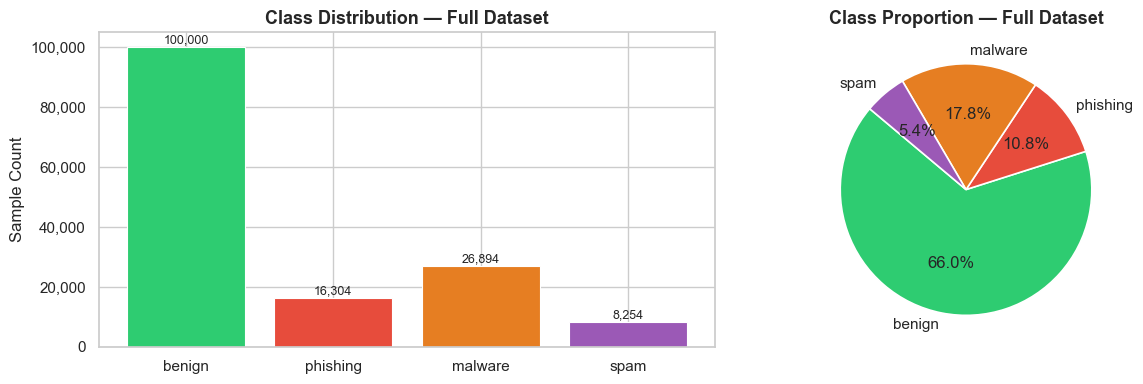


Note: benign is capped at 100,000 (raw file has ~988k entries).


In [35]:
## 1.4 Class Distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Bar chart (full dataset counts) ---
full_counts = df_full["label_name"].value_counts().reindex(CLASS_NAMES)
bars = axes[0].bar(CLASS_NAMES, full_counts.values, color=CLASS_COLORS, edgecolor="white", linewidth=0.8)
axes[0].set_title("Class Distribution — Full Dataset", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Sample Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, full_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 400,
                 f"{val:,}", ha="center", va="bottom", fontsize=9)

# --- Pie chart ---
axes[1].pie(
    full_counts.values,
    labels=CLASS_NAMES,
    colors=CLASS_COLORS,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2},
)
axes[1].set_title("Class Proportion — Full Dataset", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nNote: benign is capped at 100,000 (raw file has ~988k entries).")

C:\Users\dimas\AppData\Local\Temp\ipykernel_41444\3467981532.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\dimas\AppData\Local\Temp\ipykernel_41444\3467981532.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\dimas\AppData\Local\Temp\ipykernel_41444\3467981532.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


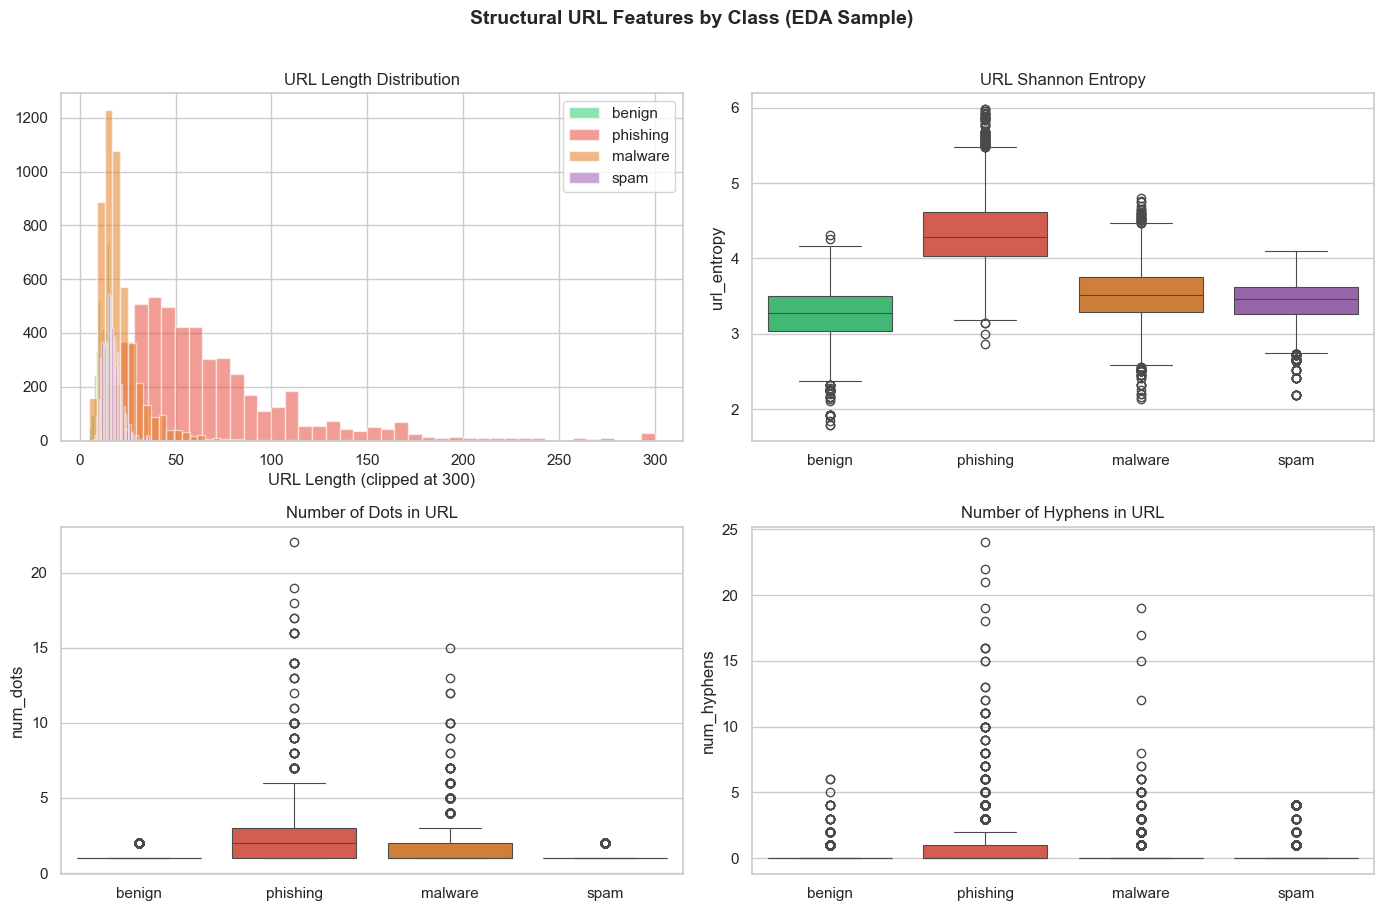

In [36]:
## 1.5 URL Length & Structural Features by Class

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- URL length histogram ---
for name, color in CLASS_PALETTE.items():
    subset = df_feat[df_feat["label_name"] == name]["url_length"]
    axes[0, 0].hist(subset.clip(upper=300), bins=40, alpha=0.55, label=name, color=color)
axes[0, 0].set_title("URL Length Distribution")
axes[0, 0].set_xlabel("URL Length (clipped at 300)")
axes[0, 0].legend()

# --- URL entropy box plot ---
sns.boxplot(
    data=df_feat, x="label_name", y="url_entropy",
    order=CLASS_NAMES, palette=CLASS_PALETTE, ax=axes[0, 1],
    linewidth=0.8,
)
axes[0, 1].set_title("URL Shannon Entropy")
axes[0, 1].set_xlabel("")

# --- Number of dots box plot ---
sns.boxplot(
    data=df_feat, x="label_name", y="num_dots",
    order=CLASS_NAMES, palette=CLASS_PALETTE, ax=axes[1, 0],
    linewidth=0.8,
)
axes[1, 0].set_title("Number of Dots in URL")
axes[1, 0].set_xlabel("")

# --- Number of hyphens box plot ---
sns.boxplot(
    data=df_feat, x="label_name", y="num_hyphens",
    order=CLASS_NAMES, palette=CLASS_PALETTE, ax=axes[1, 1],
    linewidth=0.8,
)
axes[1, 1].set_title("Number of Hyphens in URL")
axes[1, 1].set_xlabel("")

plt.suptitle("Structural URL Features by Class (EDA Sample)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

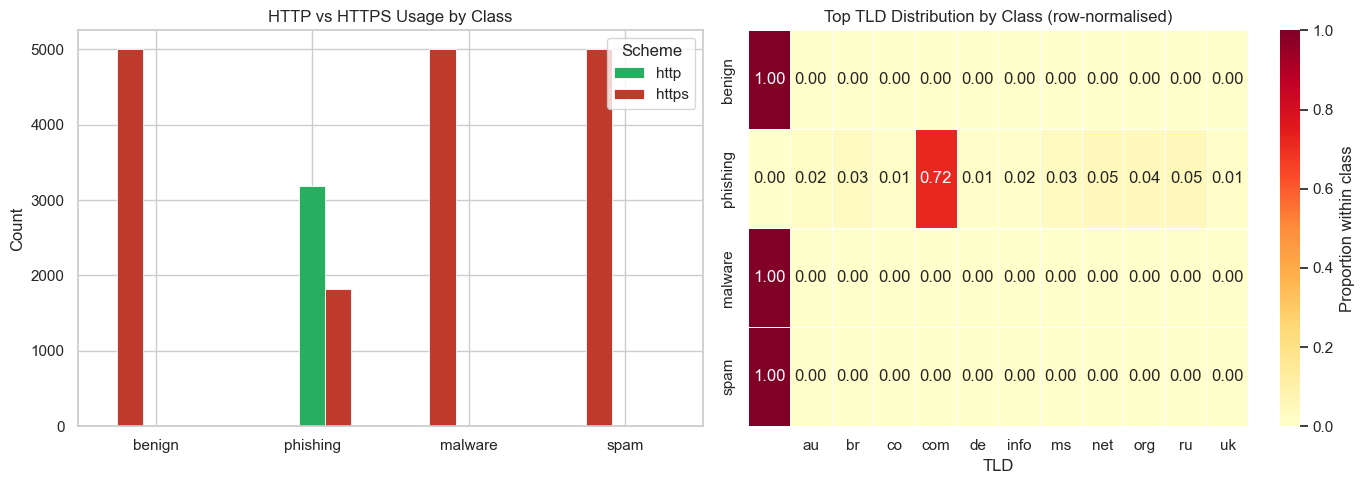

In [37]:
## 1.6 HTTPS Usage & TLD Analysis by Class

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- HTTPS usage stacked bar ---
https_counts = (
    df_feat.groupby(["label_name", "scheme"])
    .size()
    .unstack(fill_value=0)
    .reindex(CLASS_NAMES)
)
https_counts.plot(
    kind="bar", ax=axes[0],
    color=["#c0392b", "#27ae60"],
    edgecolor="white", linewidth=0.6,
)
axes[0].set_title("HTTP vs HTTPS Usage by Class")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("")
axes[0].set_xticklabels(CLASS_NAMES, rotation=0)
axes[0].legend(title="Scheme")

# --- Top 8 TLDs per class (heatmap) ---
top_tlds = df_feat["tld"].value_counts().head(12).index.tolist()
tld_matrix = (
    df_feat[df_feat["tld"].isin(top_tlds)]
    .groupby(["label_name", "tld"])
    .size()
    .unstack(fill_value=0)
    .reindex(CLASS_NAMES)
    .fillna(0)
)
# Normalise per class so scale differences don't hide patterns
tld_norm = tld_matrix.div(tld_matrix.sum(axis=1), axis=0)
sns.heatmap(
    tld_norm, ax=axes[1], cmap="YlOrRd",
    linewidths=0.4, annot=True, fmt=".2f",
    cbar_kws={"label": "Proportion within class"},
)
axes[1].set_title("Top TLD Distribution by Class (row-normalised)")
axes[1].set_xlabel("TLD")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

=== Per-class feature means (EDA sample) ===

label_name        benign  phishing  malware    spam
url_length        14.392    69.667   20.980  16.606
hostname_length    0.000    19.640    0.000   0.000
path_length       14.392    30.034   20.980  16.606
num_dots           1.099     2.333    1.524   1.039
num_hyphens        0.115     0.840    0.316   0.362
num_digits         0.231     7.892    0.795   0.617
url_entropy        3.262     4.360    3.525   3.441
hostname_entropy   0.000     3.433    0.000   0.000
has_ip_address     0.000     0.012    0.000   0.000
has_https          0.000     0.364    0.000   0.000
has_at_symbol      0.000     0.010    0.000   0.000
subdomain_count    0.000     0.706    0.000   0.000
tld_length         0.000     2.736    0.000   0.000
vowel_ratio        0.000     0.341    0.000   0.000


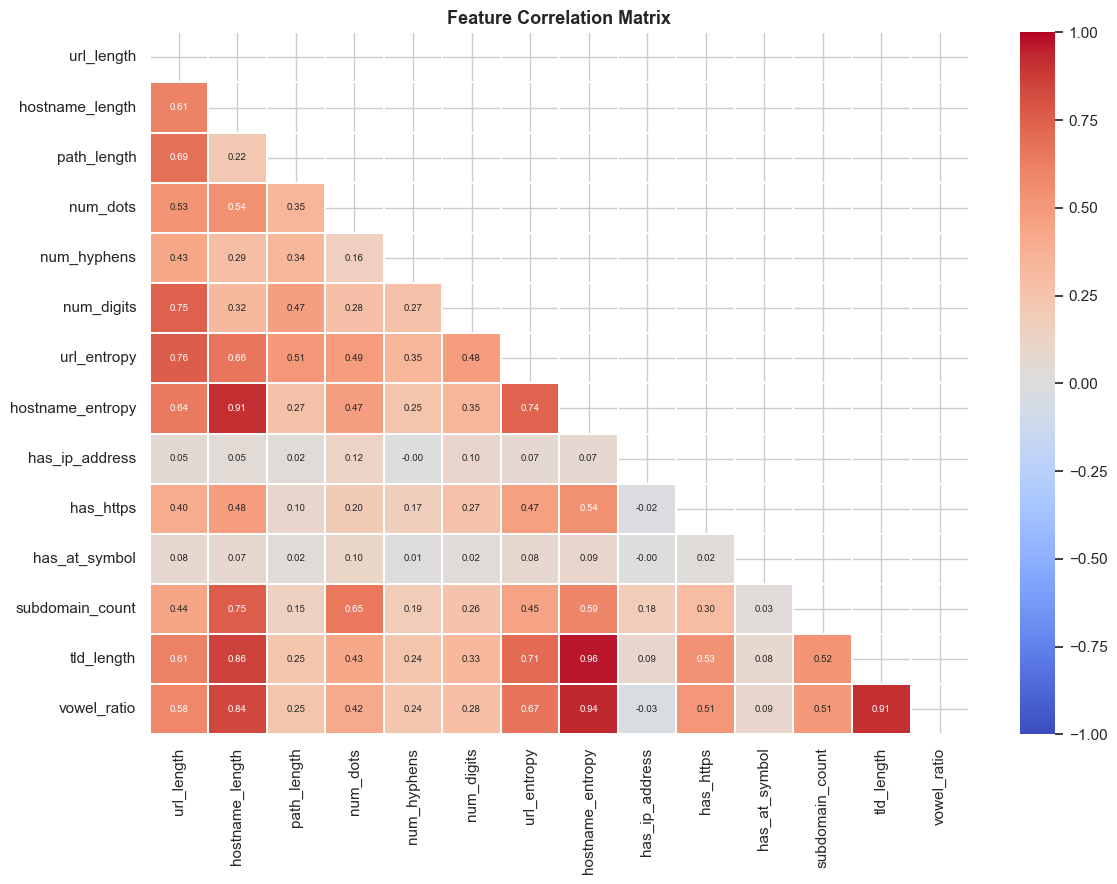


EDA sample saved → d:\PhishScamSense\data\processed\eda_sample_with_features.csv


In [38]:
## 1.7 Summary Statistics & Feature Correlation

# Per-class mean for all numerical features
numeric_cols = [
    "url_length", "hostname_length", "path_length",
    "num_dots", "num_hyphens", "num_digits",
    "url_entropy", "hostname_entropy",
    "has_ip_address", "has_https", "has_at_symbol",
    "subdomain_count", "tld_length", "vowel_ratio",
]
summary = df_feat.groupby("label_name")[numeric_cols].mean().T.reindex(columns=CLASS_NAMES)
print("=== Per-class feature means (EDA sample) ===\n")
print(summary.round(3).to_string())

# --- Correlation heatmap (all classes combined) ---
fig, ax = plt.subplots(figsize=(12, 9))
corr = df_feat[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax, cmap="coolwarm",
    center=0, linewidths=0.3, annot=True, fmt=".2f", annot_kws={"size": 7},
    vmin=-1, vmax=1,
)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Save EDA sample with features to data/processed/ for downstream notebooks
PROCESSED_DIR = Path(PROJECT_ROOT) / "data" / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)
out_path = PROCESSED_DIR / "eda_sample_with_features.csv"
df_feat.to_csv(out_path, index=False)
print(f"\nEDA sample saved → {out_path}")

---

# Part 02 — Feature Engineering

---

# 02 - Feature Engineering
## PhishScamSense: Real-Time Multimodal Phishing Defense

This notebook covers:
1. Loading the CIC-Bell-DNS2021 EDA sample from notebook 01
2. Lexical & structural feature extraction (23 features)
3. Shannon entropy and typosquatting indicators
4. Per-class feature distributions (4 classes: benign, phishing, malware, spam)
5. Feature correlation analysis across all classes

In [39]:
import sys
import os
from urllib.parse import urlparse

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ml.src.features.url_features import extract_url_features

sns.set_theme(style="whitegrid")

CLASS_NAMES  = ["benign", "phishing", "malware", "spam"]
CLASS_COLORS = ["#2ecc71", "#e74c3c", "#e67e22", "#9b59b6"]
CLASS_PALETTE = dict(zip(CLASS_NAMES, CLASS_COLORS))

PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
csv_path = os.path.join(PROCESSED_DIR, "eda_sample_with_features.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Loaded EDA sample: {df.shape}")
    print(df["label_name"].value_counts().reindex(CLASS_NAMES).to_string())
else:
    print("Run notebook 01 first to generate eda_sample_with_features.csv")

df.head()

Loaded EDA sample: (20000, 29)
label_name
benign      5000
phishing    5000
malware     5000
spam        5000


,url_length,hostname_length,path_length,num_dots,num_hyphens,num_underscores,num_slashes,num_query_params,num_fragments,num_digits,...,subdomain_count,tld_length,consecutive_consonants_max,vowel_ratio,label,label_name,url,scheme,hostname,tld
0,14,0,14,1,0,0,0,0,0,0,...,0,0,0,0.0,0,benign,libertymrp.com,NaN,NaN,NaN
1,16,0,16,1,0,0,0,0,0,0,...,0,0,0,0.0,0,benign,gsitecrawler.com,NaN,NaN,NaN
2,19,0,19,1,1,0,0,0,0,0,...,0,0,0,0.0,0,benign,spectrum-health.org,NaN,NaN,NaN
3,9,0,9,2,0,0,0,0,0,0,...,0,0,0,0.0,0,benign,nd.gov.hk,NaN,NaN,NaN
4,21,0,21,2,0,0,0,0,0,0,...,0,0,0,0.0,0,benign,cheapelectrical.co.uk,NaN,NaN,NaN


## 2.1 Feature Extraction Functions

All 23 features used by the numerical branch (MLP/CapsNet) are implemented in
`ml/src/features/url_features.py` and imported above. This cell demonstrates each feature
on a real example from each class.

In [40]:
# Show one representative URL per class and its extracted features
examples = (
    df.groupby("label_name", group_keys=False)
    .apply(lambda g: g.sample(1, random_state=0))
    .reset_index(drop=True)
)

for _, row in examples.iterrows():
    url = row["url"]
    feat = extract_url_features(url)
    print(f"\n[{row['label_name'].upper()}]  {url}")
    print(f"  {'Feature':<35} Value")
    print(f"  {'-'*50}")
    for k, v in feat.items():
        print(f"  {k:<35} {v}")

print(f"\nTotal features per URL: {len(feat)}")


[BENIGN]  fark.ru
  Feature                             Value
  --------------------------------------------------
  url_length                          7
  hostname_length                     0
  path_length                         7
  num_dots                            1
  num_hyphens                         0
  num_underscores                     0
  num_slashes                         0
  num_query_params                    0
  num_fragments                       0
  num_digits                          0
  num_special_chars                   0
  url_entropy                         2.5216406363433186
  hostname_entropy                    0.0
  has_ip_address                      0
  has_punycode                        False
  has_port                            0
  has_https                           0
  has_at_symbol                       0
  has_double_slash_redirect           0
  subdomain_count                     0
  tld_length                          0
  consecutive_consona

C:\Users\dimas\AppData\Local\Temp\ipykernel_41444\257203954.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(1, random_state=0))


## 2.2 Extract Features for Entire Dataset

## 2.2 Feature Matrix

The EDA sample loaded from notebook 01 already contains all 23 extracted features.
We select only the numerical feature columns here.

FEATURE_COLS = [
    "url_length", "hostname_length", "path_length", "num_dots", "num_hyphens",
    "num_underscores", "num_slashes", "num_query_params", "num_fragments",
    "num_digits", "num_special_chars", "url_entropy", "hostname_entropy",
    "has_ip_address", "has_punycode", "has_port", "has_https", "has_at_symbol",
    "has_double_slash_redirect", "subdomain_count", "tld_length",
    "consecutive_consonants_max", "vowel_ratio",
]

In [41]:
FEATURE_COLS = [
    "url_length", "hostname_length", "path_length", "num_dots", "num_hyphens",
    "num_underscores", "num_slashes", "num_query_params", "num_fragments",
    "num_digits", "num_special_chars", "url_entropy", "hostname_entropy",
    "has_ip_address", "has_punycode", "has_port", "has_https", "has_at_symbol",
    "has_double_slash_redirect", "subdomain_count", "tld_length",
    "consecutive_consonants_max", "vowel_ratio",
]

features_df = df[FEATURE_COLS + ["label", "label_name"]].copy()
print(f"Feature matrix: {features_df.shape}")
features_df.head()

Feature matrix: (20000, 25)


,url_length,hostname_length,path_length,num_dots,num_hyphens,num_underscores,num_slashes,num_query_params,num_fragments,num_digits,...,has_port,has_https,has_at_symbol,has_double_slash_redirect,subdomain_count,tld_length,consecutive_consonants_max,vowel_ratio,label,label_name
0,14,0,14,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.0,0,benign
1,16,0,16,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.0,0,benign
2,19,0,19,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0.0,0,benign
3,9,0,9,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.0,0,benign
4,21,0,21,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.0,0,benign


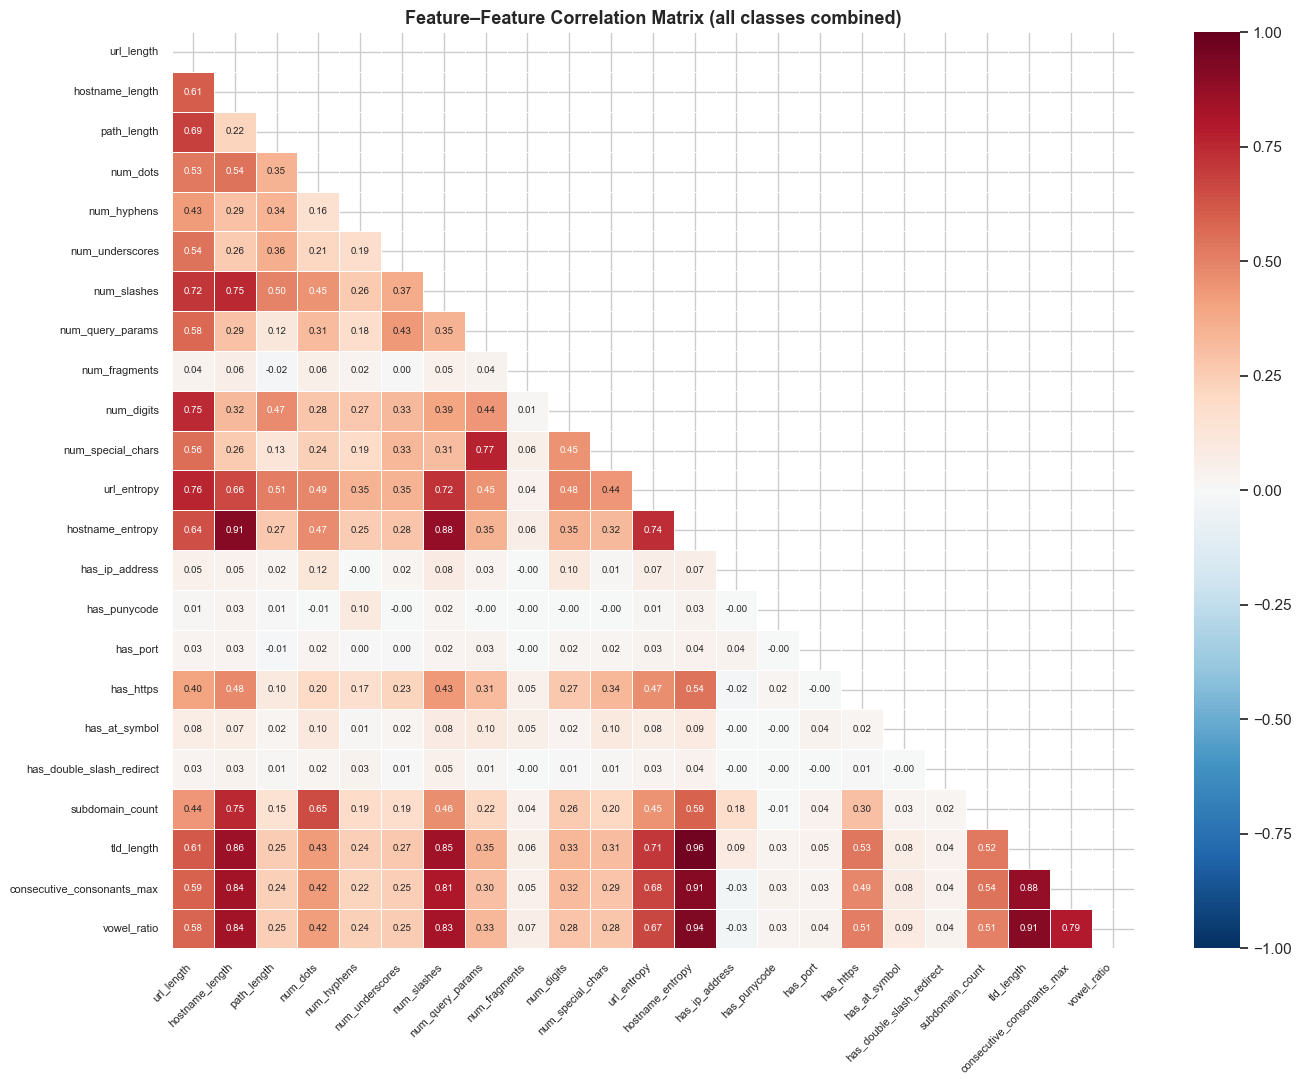

In [42]:
## 2.3 Feature Correlation Matrix

fig, ax = plt.subplots(figsize=(14, 11))
corr = features_df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    ax=ax, linewidths=0.4, annot_kws={"size": 7}, vmin=-1, vmax=1,
)
ax.set_title("Feature–Feature Correlation Matrix (all classes combined)", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Features ranked by cross-class discriminability (std of per-class means):

url_length                    26.3135
hostname_length                9.8199
path_length                    6.9186
num_digits                     3.6796
num_slashes                    2.5141
hostname_entropy               1.7165
consecutive_consonants_max     1.4059
tld_length                     1.3681
num_special_chars              0.6287
num_dots                       0.5969
url_entropy                    0.4875
subdomain_count                0.3531
num_hyphens                    0.3070
num_query_params               0.2156
has_https                      0.1818
vowel_ratio                    0.1705
num_underscores                0.1476
has_ip_address                 0.0061
has_at_symbol                  0.0052
num_fragments                  0.0024
has_port                       0.0012
has_double_slash_redirect      0.0011
has_punycode                   0.0007


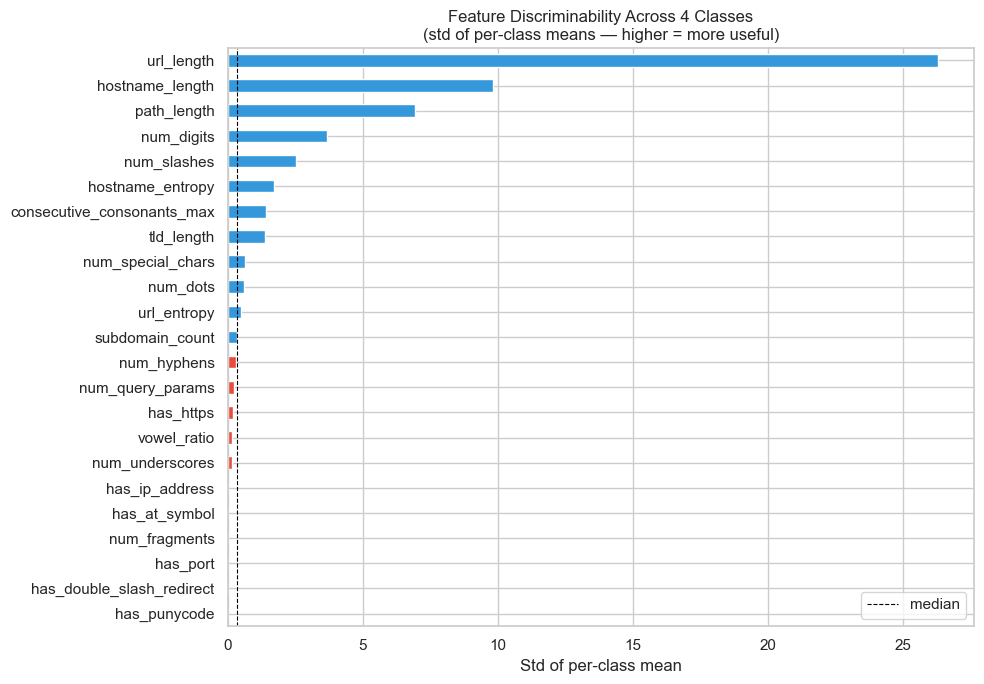

In [43]:
# Per-class mean feature values — ranks each feature by how much it differs across classes
per_class_means = features_df.groupby("label_name")[FEATURE_COLS].mean().T.reindex(columns=CLASS_NAMES)

# Feature discriminability: std of per-class means (high = more discriminative)
discriminability = per_class_means.std(axis=1).sort_values(ascending=False)

print("Features ranked by cross-class discriminability (std of per-class means):\n")
print(discriminability.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#e74c3c" if v > discriminability.median() else "#3498db"
          for v in discriminability.values]
discriminability.plot(kind="barh", ax=ax, color=colors[::-1])
ax.invert_yaxis()
ax.set_title("Feature Discriminability Across 4 Classes\n(std of per-class means — higher = more useful)")
ax.set_xlabel("Std of per-class mean")
ax.axvline(discriminability.median(), color="black", linewidth=0.8, linestyle="--", label="median")
ax.legend()
plt.tight_layout()
plt.show()

## 2.4 Feature Distributions by Class

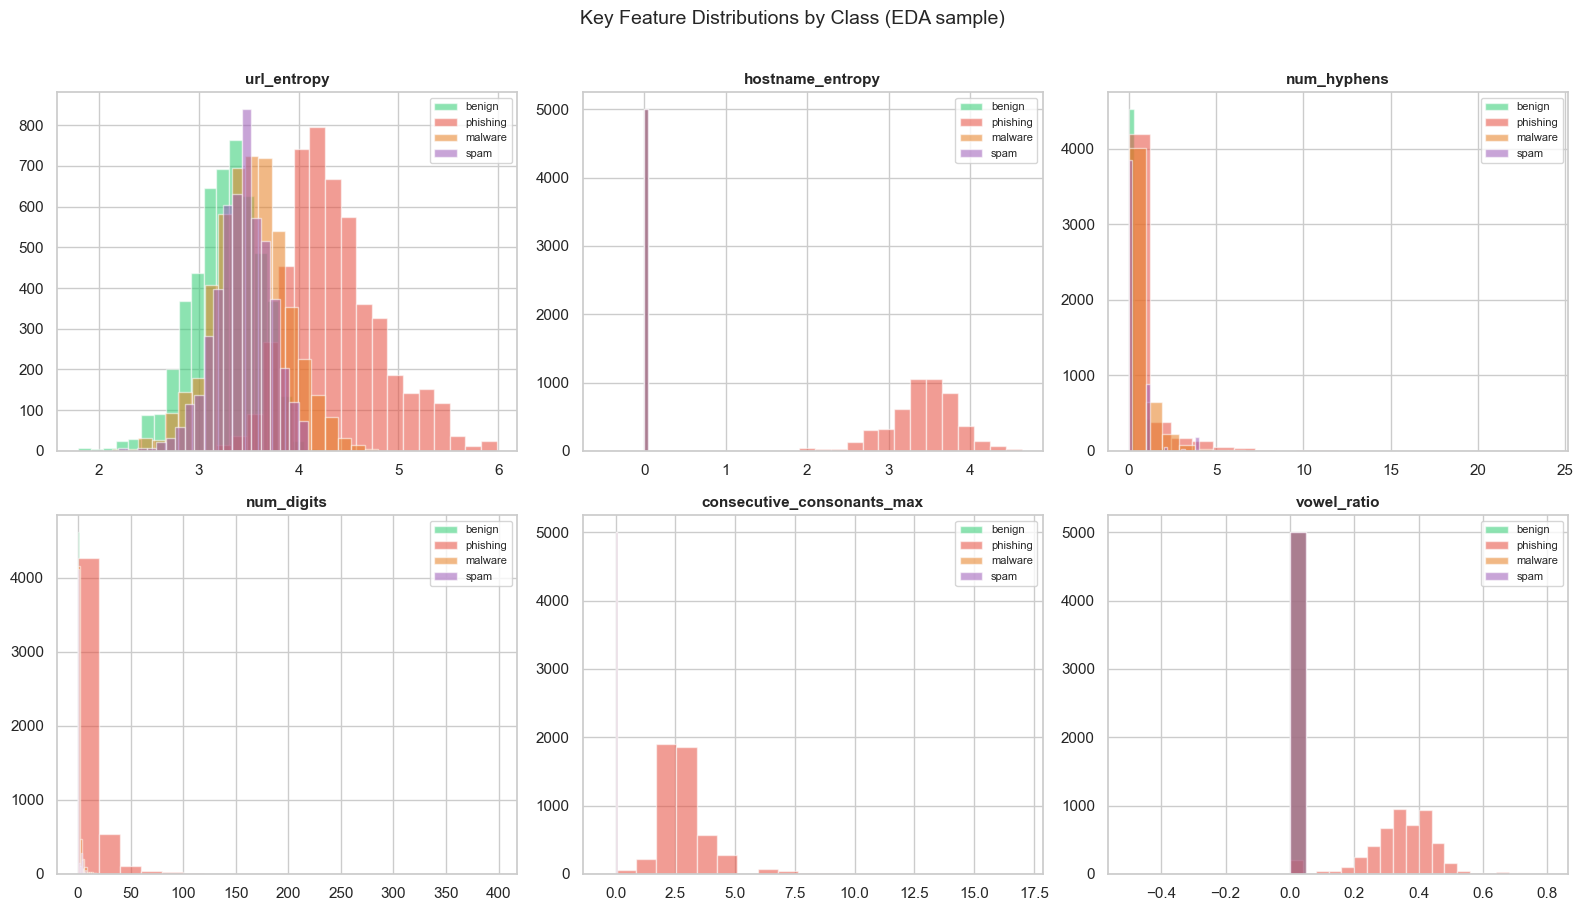

In [44]:
key_features = [
    "url_entropy", "hostname_entropy", "num_hyphens", "num_digits",
    "consecutive_consonants_max", "vowel_ratio",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for name, color in CLASS_PALETTE.items():
        subset = features_df[features_df["label_name"] == name][feat]
        axes[i].hist(subset, bins=20, alpha=0.55, label=name, color=color)
    axes[i].set_title(feat, fontsize=11, fontweight="bold")
    axes[i].legend(fontsize=8)

plt.suptitle("Key Feature Distributions by Class (EDA sample)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [45]:
# Save feature matrix for use in training notebooks
out_path = os.path.join(PROCESSED_DIR, "features_dataset.csv")
features_df.to_csv(out_path, index=False)
print(f"Feature dataset saved → {out_path}")
print(f"Shape: {features_df.shape}")
print(f"Columns: {list(features_df.columns)}")

Feature dataset saved → d:\PhishScamSense\data\processed\features_dataset.csv
Shape: (20000, 25)
Columns: ['url_length', 'hostname_length', 'path_length', 'num_dots', 'num_hyphens', 'num_underscores', 'num_slashes', 'num_query_params', 'num_fragments', 'num_digits', 'num_special_chars', 'url_entropy', 'hostname_entropy', 'has_ip_address', 'has_punycode', 'has_port', 'has_https', 'has_at_symbol', 'has_double_slash_redirect', 'subdomain_count', 'tld_length', 'consecutive_consonants_max', 'vowel_ratio', 'label', 'label_name']


---

# Part 03 — Model Architecture

---

# 03 - Model Architecture
## PhishScamSense: Multimodal Fusion Model

This notebook covers:
1. **NLP Branch**: DistilBERT + BiLSTM + Attention for URL text processing
2. **Numerical Branch**: MLP and CapsNet for 23 engineered features
3. **Fusion Model**: Hierarchical concatenation of both branches
4. **XGBoost Classifier**: 4-class final decision-maker on fused features
5. Architecture visualization and parameter counts

```
                    ┌─────────────────────────────────────┐
                    │           Input: URL String          │
                    └──────────┬──────────┬───────────────┘
                               │          │
                    ┌──────────▼──┐  ┌────▼──────────────┐
                    │  NLP Branch │  │ Numerical Branch   │
                    │             │  │                    │
                    │ DistilBERT  │  │ Feature Extraction │
                    │     ↓       │  │ (23 features)      │
                    │  BiLSTM     │  │       ↓            │
                    │     ↓       │  │  MLP / CapsNet     │
                    │ Attention   │  │                    │
                    │     ↓       │  │       ↓            │
                    │  FC (128d)  │  │   FC (64d)         │
                    └──────┬──────┘  └────┬───────────────┘
                           │              │
                    ┌──────▼──────────────▼───────────────┐
                    │   Concatenation (192d fused vector)  │
                    └──────────────┬──────────────────────┘
                                   │
                    ┌──────────────▼──────────────────────┐
                    │       XGBoost Classifier             │
                    │  4-class: benign / phishing /        │
                    │           malware / spam             │
                    └─────────────────────────────────────┘
```

In [46]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

import torch
import torch.nn as nn
from transformers import DistilBertModel, DistilBertTokenizer

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

PyTorch version: 2.5.1+cpu
CUDA available: False
Using device: cpu


## 3.1 NLP Branch: DistilBERT + BiLSTM + Attention

This branch processes the URL as a text string:
- **DistilBERT**: Pre-trained language model extracts contextual token embeddings (768d)
- **BiLSTM**: Captures sequential dependencies in both directions
- **Attention**: Learns to focus on suspicious tokens/subwords
- **FC**: Projects to 128-dimensional output vector

In [47]:
class AttentionLayer(nn.Module):
    """Attention mechanism to weight important tokens in URL."""

    def __init__(self, hidden_size: int):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, lstm_output: torch.Tensor) -> torch.Tensor:
        # lstm_output shape: (batch, seq_len, hidden*2)
        weights = torch.softmax(self.attention(lstm_output), dim=1)  # (batch, seq_len, 1)
        return torch.sum(weights * lstm_output, dim=1)  # (batch, hidden*2)


class NLPBranch(nn.Module):
    """
    DistilBERT -> BiLSTM -> Attention -> FC
    Processes URL string to extract semantic features.
    """

    def __init__(
        self,
        output_dim: int = 128,
        lstm_hidden: int = 256,
        lstm_layers: int = 2,
        dropout: float = 0.3,
        freeze_bert: bool = True,
    ):
        super().__init__()

        self.distilbert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        if freeze_bert:
            for param in self.distilbert.parameters():
                param.requires_grad = False

        bert_hidden = self.distilbert.config.hidden_size  # 768

        self.bilstm = nn.LSTM(
            input_size=bert_hidden,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0,
        )

        self.attention = AttentionLayer(lstm_hidden * 2)  # *2 for bidirectional
        self.fc = nn.Linear(lstm_hidden * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        # DistilBERT encoding
        bert_output = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = bert_output.last_hidden_state  # (batch, seq_len, 768)

        # BiLSTM
        lstm_output, _ = self.bilstm(sequence_output)  # (batch, seq_len, hidden*2)

        # Attention pooling
        attended = self.attention(lstm_output)  # (batch, hidden*2)

        # Final projection
        output = self.fc(self.dropout(attended))  # (batch, output_dim)
        return output


class URLTokenizer:
    """Tokenizes URLs for DistilBERT input."""

    def __init__(self, max_length: int = 128):
        self.tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
        self.max_length = max_length

    def tokenize(self, urls: list[str]) -> dict:
        return self.tokenizer(
            urls,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )


print("NLP Branch defined successfully.")

NLP Branch defined successfully.


In [48]:
# Test NLP Branch
nlp_branch = NLPBranch(output_dim=128, freeze_bert=True)

tokenizer = URLTokenizer()
test_urls = ["https://www.google.com", "http://paypa1-secure.tk/login"]
tokens = tokenizer.tokenize(test_urls)

with torch.no_grad():
    nlp_output = nlp_branch(tokens["input_ids"], tokens["attention_mask"])

print(f"Input token shape:  {tokens['input_ids'].shape}")
print(f"NLP Branch output:  {nlp_output.shape}")
print(f"Expected:           (2, 128)")

Input token shape:  torch.Size([2, 17])
NLP Branch output:  torch.Size([2, 128])
Expected:           (2, 128)


## 3.2 Numerical Branch: MLP

Processes the **23** engineered features through a multi-layer perceptron with batch normalization and dropout.

In [49]:
class MLPBranch(nn.Module):
    """Multi-Layer Perceptron for processing numerical URL features."""

    def __init__(
        self,
        input_dim: int = 23,
        hidden_dims: list[int] | None = None,
        output_dim: int = 64,
        dropout: float = 0.3,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [128, 64]

        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


# Test MLP Branch
mlp_branch = MLPBranch(input_dim=23, output_dim=64)
dummy_features = torch.randn(2, 23)

with torch.no_grad():
    mlp_output = mlp_branch(dummy_features)

print(f"MLP input shape:   {dummy_features.shape}")
print(f"MLP output shape:  {mlp_output.shape}")
print(f"Expected:          (2, 64)")
print(f"\nMLP Architecture:\n{mlp_branch}")

MLP input shape:   torch.Size([2, 23])
MLP output shape:  torch.Size([2, 64])
Expected:          (2, 64)

MLP Architecture:
MLPBranch(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=64, bias=True)
  )
)


## 3.3 Alternative Numerical Branch: Capsule Neural Network (CapsNet)

CapsNet preserves hierarchical structural information from engineered URL features without losing spatial properties.

In [50]:
class PrimaryCapsule(nn.Module):
    """Primary capsule layer for CapsNet."""

    def __init__(self, in_channels: int, out_channels: int, capsule_dim: int):
        super().__init__()
        self.capsule_dim = capsule_dim
        self.conv = nn.Linear(in_channels, out_channels * capsule_dim)
        self.out_channels = out_channels

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output = self.conv(x)
        return output.view(-1, self.out_channels, self.capsule_dim)


def squash(tensor: torch.Tensor, dim: int = -1) -> torch.Tensor:
    """Squash activation function for capsule networks."""
    squared_norm = (tensor**2).sum(dim=dim, keepdim=True)
    scale = squared_norm / (1 + squared_norm)
    return scale * tensor / (torch.sqrt(squared_norm) + 1e-8)


class CapsNetBranch(nn.Module):
    """
    Capsule Neural Network for preserving hierarchical structural
    information from engineered URL features.
    """

    def __init__(
        self,
        input_dim: int = 23,
        primary_caps: int = 8,
        capsule_dim: int = 8,
        output_dim: int = 64,
    ):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.primary_capsules = PrimaryCapsule(128, primary_caps, capsule_dim)
        self.fc_out = nn.Linear(primary_caps * capsule_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.relu(self.bn1(self.fc1(x)))
        capsules = self.primary_capsules(x)
        capsules = squash(capsules)
        flattened = capsules.view(capsules.size(0), -1)
        return self.fc_out(flattened)


# Test CapsNet Branch
capsnet_branch = CapsNetBranch(input_dim=23, output_dim=64)
dummy_features = torch.randn(2, 23)

with torch.no_grad():
    caps_output = capsnet_branch(dummy_features)

print(f"CapsNet input shape:   {dummy_features.shape}")
print(f"CapsNet output shape:  {caps_output.shape}")
print(f"Expected:              (2, 64)")
print(f"\nCapsNet Architecture:\n{capsnet_branch}")

CapsNet input shape:   torch.Size([2, 23])
CapsNet output shape:  torch.Size([2, 64])
Expected:              (2, 64)

CapsNet Architecture:
CapsNetBranch(
  (fc1): Linear(in_features=23, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (primary_capsules): PrimaryCapsule(
    (conv): Linear(in_features=128, out_features=64, bias=True)
  )
  (fc_out): Linear(in_features=64, out_features=64, bias=True)
)


## 3.4 Fusion Model: Combining Both Branches

The fusion model concatenates outputs from both branches into a single 192-dimensional feature vector.

In [51]:
import xgboost as xgb
import numpy as np

NUM_CLASSES = 4  # 0=benign  1=phishing  2=malware  3=spam


class PhishScamSenseFusionModel(nn.Module):
    """
    Hierarchical fusion model combining NLP and Numerical branches.
    Output: 192-dimensional fused embedding (128 NLP + 64 numerical).
    """

    def __init__(
        self,
        num_features: int = 23,
        nlp_output_dim: int = 128,
        numerical_output_dim: int = 64,
        freeze_bert: bool = True,
    ):
        super().__init__()

        self.nlp_branch = NLPBranch(output_dim=nlp_output_dim, freeze_bert=freeze_bert)
        self.numerical_branch = MLPBranch(input_dim=num_features, output_dim=numerical_output_dim)
        self.fusion_dim = nlp_output_dim + numerical_output_dim

    def forward(self, input_ids, attention_mask, numerical_features):
        nlp_output = self.nlp_branch(input_ids, attention_mask)
        numerical_output = self.numerical_branch(numerical_features)
        return torch.cat([nlp_output, numerical_output], dim=1)


class PhishScamSenseClassifier:
    """
    Complete PhishScamSense classifier:
    Neural feature extractor + XGBoost 4-class final classifier.
    """

    def __init__(self, fusion_model: PhishScamSenseFusionModel):
        self.fusion_model = fusion_model
        self.xgb_classifier = xgb.XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            objective="multi:softmax",
            num_class=NUM_CLASSES,
            eval_metric="mlogloss",
            n_jobs=-1,
        )

    def extract_features(self, input_ids, attention_mask, numerical_features) -> np.ndarray:
        self.fusion_model.eval()
        with torch.no_grad():
            fused = self.fusion_model(input_ids, attention_mask, numerical_features)
        return fused.cpu().numpy()

    def fit(self, input_ids, attention_mask, numerical_features, labels):
        features = self.extract_features(input_ids, attention_mask, numerical_features)
        self.xgb_classifier.fit(features, labels)

    def predict(self, input_ids, attention_mask, numerical_features) -> np.ndarray:
        """Return predicted class indices (int)."""
        features = self.extract_features(input_ids, attention_mask, numerical_features)
        return self.xgb_classifier.predict(features)

    def predict_proba(self, input_ids, attention_mask, numerical_features) -> np.ndarray:
        """Return class probabilities, shape (n, 4)."""
        features = self.extract_features(input_ids, attention_mask, numerical_features)
        return self.xgb_classifier.predict_proba(features)


print("PhishScamSenseFusionModel and PhishScamSenseClassifier defined.")

PhishScamSenseFusionModel and PhishScamSenseClassifier defined.


## 3.5 Test Full Fusion Pipeline & Parameter Summary

In [52]:
# Instantiate full fusion model
fusion_model = PhishScamSenseFusionModel(num_features=23, freeze_bert=True)

# Test forward pass with dummy data
dummy_input_ids      = torch.randint(0, 30522, (2, 32))
dummy_attention_mask = torch.ones(2, 32, dtype=torch.long)
dummy_numerical      = torch.randn(2, 23)

with torch.no_grad():
    fused_output = fusion_model(dummy_input_ids, dummy_attention_mask, dummy_numerical)

print(f"Fused output shape: {fused_output.shape}")
print(f"Fusion dimension:   {fusion_model.fusion_dim}")
print(f"Expected:           (2, 192)")

# Parameter count
def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable, total - trainable

total, trainable, frozen = count_parameters(fusion_model)
print(f"\n{'='*50}")
print(f"PARAMETER SUMMARY")
print(f"{'='*50}")
print(f"Total parameters:     {total:>12,}")
print(f"Trainable parameters: {trainable:>12,}")
print(f"Frozen parameters:    {frozen:>12,}  (DistilBERT, freeze_bert=True)")
print(f"{'='*50}")

nlp_total, nlp_train, _ = count_parameters(fusion_model.nlp_branch)
num_total, num_train, _ = count_parameters(fusion_model.numerical_branch)
print(f"\nNLP Branch:       {nlp_total:>10,} total  |  {nlp_train:>10,} trainable")
print(f"Numerical Branch: {num_total:>10,} total  |  {num_train:>10,} trainable")
print(f"\nXGBoost 4-class head is trained separately on 192-d fused embeddings.")

Fused output shape: torch.Size([2, 192])
Fusion dimension:   192
Expected:           (2, 192)

PARAMETER SUMMARY
Total parameters:       70,123,137
Trainable parameters:    3,760,257
Frozen parameters:      66,362,880  (DistilBERT, freeze_bert=True)

NLP Branch:       70,107,265 total  |   3,744,385 trainable
Numerical Branch:     15,872 total  |      15,872 trainable

XGBoost 4-class head is trained separately on 192-d fused embeddings.


---

# Part 04 — Training Pipeline

---

# 04 - Training Pipeline
## PhishScamSense: Real-Time Multimodal Phishing Defense

This notebook covers:
1. Loading a training subset from the CIC-Bell-DNS2021 dataset
2. Preparing tokenized + numerical features for all 4 classes
3. Pre-training the fusion model (neural network branches) with CrossEntropyLoss
4. Training the XGBoost 4-class classifier on fused embeddings
5. MLflow experiment tracking and model checkpointing

> **Full training:** run `python -m ml.src.training.train --mode xgboost` from the project root.
> This notebook uses a small subset (≤2,000 per class) for demonstration.

In [53]:
import sys
import os
import logging
from pathlib import Path

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import xgboost as xgb
import matplotlib.pyplot as plt

from ml.src.data.data_loader import load_cic_bell_dns2021
from ml.src.features.url_features import extract_url_features

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(levelname)-8s  %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger(__name__)

CLASS_NAMES  = ["benign", "phishing", "malware", "spam"]
NUM_CLASSES  = 4
DATA_DIR     = Path(PROJECT_ROOT) / "data" / "raw"
CHECKPOINT_DIR = Path(PROJECT_ROOT) / "ml" / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 4.1 Define All Model Components

Re-define model classes here so this notebook is self-contained and runnable.

In [54]:
from transformers import DistilBertModel, DistilBertTokenizer

# ── Model classes (mirrors ml/src/models/) ──────────────────────────────────

class AttentionLayer(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)
    def forward(self, lstm_output):
        weights = torch.softmax(self.attention(lstm_output), dim=1)
        return torch.sum(weights * lstm_output, dim=1)

class NLPBranch(nn.Module):
    def __init__(self, output_dim=128, lstm_hidden=256, lstm_layers=2, dropout=0.3, freeze_bert=True):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        if freeze_bert:
            for param in self.distilbert.parameters():
                param.requires_grad = False
        bert_hidden = self.distilbert.config.hidden_size
        self.bilstm = nn.LSTM(bert_hidden, lstm_hidden, lstm_layers, batch_first=True,
                              bidirectional=True, dropout=dropout if lstm_layers > 1 else 0)
        self.attention = AttentionLayer(lstm_hidden * 2)
        self.fc = nn.Linear(lstm_hidden * 2, output_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, input_ids, attention_mask):
        bert_out = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        lstm_out, _ = self.bilstm(bert_out.last_hidden_state)
        attended = self.attention(lstm_out)
        return self.fc(self.dropout(attended))

class MLPBranch(nn.Module):
    def __init__(self, input_dim=23, hidden_dims=None, output_dim=64, dropout=0.3):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [128, 64]
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.extend([nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)])
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x)

class PhishScamSenseFusionModel(nn.Module):
    def __init__(self, num_features=23, nlp_output_dim=128, numerical_output_dim=64, freeze_bert=True):
        super().__init__()
        self.nlp_branch = NLPBranch(output_dim=nlp_output_dim, freeze_bert=freeze_bert)
        self.numerical_branch = MLPBranch(input_dim=num_features, output_dim=numerical_output_dim)
        self.fusion_dim = nlp_output_dim + numerical_output_dim
    def forward(self, input_ids, attention_mask, numerical_features):
        nlp_out = self.nlp_branch(input_ids, attention_mask)
        num_out = self.numerical_branch(numerical_features)
        return torch.cat([nlp_out, num_out], dim=1)

class URLTokenizer:
    def __init__(self, max_length=128):
        self.tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
        self.max_length = max_length
    def tokenize(self, urls):
        return self.tokenizer(urls, padding=True, truncation=True,
                              max_length=self.max_length, return_tensors="pt")

print("All model components defined.")

All model components defined.


## 4.2 Load CIC-Bell-DNS2021 Training Subset

We cap each class to keep this notebook runnable in reasonable time.
For full training use `ml.src.training.train`.

In [55]:
import random
from sklearn.model_selection import train_test_split

SAMPLES_PER_CLASS = 2_000   # increase for better accuracy; decrease for faster runs
SEED = 42

# Load full dataset (benign capped) then subsample per class for the notebook
urls_all, labels_all = load_cic_bell_dns2021(DATA_DIR, max_benign=SAMPLES_PER_CLASS * 2, seed=SEED)

rng = random.Random(SEED)
per_class: dict[int, list[str]] = {i: [] for i in range(NUM_CLASSES)}
for url, lbl in zip(urls_all, labels_all):
    per_class[lbl].append(url)

urls, labels = [], []
for lbl, url_list in per_class.items():
    sample = rng.sample(url_list, min(SAMPLES_PER_CLASS, len(url_list)))
    urls.extend(sample)
    labels.extend([lbl] * len(sample))
    logger.info(f"  {CLASS_NAMES[lbl]:12s}: {len(sample):,}")

urls   = np.array(urls,   dtype=object)
labels = np.array(labels, dtype=np.int32)
logger.info(f"Notebook training set: {len(urls):,} URLs")

# Train / val split
X_train, X_val, y_train, y_val = train_test_split(
    urls, labels, test_size=0.15, random_state=SEED, stratify=labels
)
logger.info(f"Train: {len(X_train):,}   Val: {len(X_val):,}")

# Prepare dataset helper
def prepare_dataset(url_arr, label_arr):
    tokenizer = URLTokenizer()
    tokens = tokenizer.tokenize(url_arr.tolist())
    num_feat = [list(extract_url_features(u).values()) for u in url_arr]
    return {
        "input_ids":          tokens["input_ids"],
        "attention_mask":     tokens["attention_mask"],
        "numerical_features": torch.tensor(num_feat, dtype=torch.float32),
        "labels":             label_arr,
    }

logger.info("Tokenizing & extracting features for training set…")
train_data = prepare_dataset(X_train, y_train)
logger.info("Tokenizing & extracting features for validation set…")
val_data   = prepare_dataset(X_val, y_val)

print(f"\ninput_ids shape:          {train_data['input_ids'].shape}")
print(f"numerical_features shape: {train_data['numerical_features'].shape}")
print(f"labels unique:            {np.unique(train_data['labels'])}")

INFO:ml.src.data.data_loader:Loaded 4,000 benign URLs
INFO:ml.src.data.data_loader:Loaded 16,304 phishing URLs
INFO:ml.src.data.data_loader:Loaded 26,894 malware URLs
INFO:ml.src.data.data_loader:Loaded 8,254 spam URLs
INFO:ml.src.data.data_loader:Total dataset: 55,452 URLs
INFO:__main__:  benign      : 2,000
INFO:__main__:  phishing    : 2,000
INFO:__main__:  malware     : 2,000
INFO:__main__:  spam        : 2,000
INFO:__main__:Notebook training set: 8,000 URLs
INFO:__main__:Train: 6,800   Val: 1,200
INFO:__main__:Tokenizing & extracting features for training set…
INFO:__main__:Tokenizing & extracting features for validation set…



input_ids shape:          torch.Size([6800, 128])
numerical_features shape: torch.Size([6800, 23])
labels unique:            [0 1 2 3]


## 4.3 Train Fusion Model (Neural Network Branches)

Pre-train the neural branches using **CrossEntropyLoss** over all 4 classes.
The learned embeddings are later used as input to the XGBoost classifier.

In [56]:
def train_fusion_model(fusion_model, train_data, val_data,
                       epochs=5, batch_size=16, learning_rate=1e-4, device="cpu"):
    """Pre-train the fusion model branches with 4-class CrossEntropyLoss."""
    fusion_model = fusion_model.to(device)
    classifier_head = nn.Linear(fusion_model.fusion_dim, NUM_CLASSES).to(device)

    optimizer = torch.optim.Adam(
        list(fusion_model.parameters()) + list(classifier_head.parameters()),
        lr=learning_rate,
    )
    criterion = nn.CrossEntropyLoss()

    dataset = TensorDataset(
        train_data["input_ids"],
        train_data["attention_mask"],
        train_data["numerical_features"],
        torch.tensor(train_data["labels"], dtype=torch.long),
    )
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Validation tensors
    val_ids  = val_data["input_ids"].to(device)
    val_mask = val_data["attention_mask"].to(device)
    val_num  = val_data["numerical_features"].to(device)
    val_lbl  = torch.tensor(val_data["labels"], dtype=torch.long).to(device)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        fusion_model.train(); classifier_head.train()
        total_loss = 0.0
        for ids, mask, num_feat, lbls in dataloader:
            ids, mask, num_feat, lbls = ids.to(device), mask.to(device), num_feat.to(device), lbls.to(device)
            optimizer.zero_grad()
            logits = classifier_head(fusion_model(ids, mask, num_feat))
            loss   = criterion(logits, lbls)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(dataloader)

        # Validation
        fusion_model.eval(); classifier_head.eval()
        with torch.no_grad():
            val_logits = classifier_head(fusion_model(val_ids, val_mask, val_num))
            val_loss   = criterion(val_logits, val_lbl).item()
            val_acc    = (val_logits.argmax(dim=1) == val_lbl).float().mean().item()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        logger.info(f"Epoch {epoch+1}/{epochs}  train_loss={avg_train_loss:.4f}  "
                    f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

    return fusion_model, history

print("Training function defined.")

Training function defined.


## 4.4 Run Training with MLflow Tracking

In [58]:
try:
    import mlflow
    MLFLOW_TRACKING_URI = os.path.join(PROJECT_ROOT, "ml", "mlruns")
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment("phishscamsense")
    USE_MLFLOW = True
except Exception:
    USE_MLFLOW = False
    logger.warning("MLflow not available — skipping experiment tracking.")

EPOCHS     = 5
BATCH_SIZE = 16
LR         = 1e-4

run_ctx = mlflow.start_run(run_name="fusion_model_v1") if USE_MLFLOW else __import__("contextlib").nullcontext()

with run_ctx:
    if USE_MLFLOW:
        mlflow.log_params({
            "epochs": EPOCHS, "batch_size": BATCH_SIZE, "learning_rate": LR,
            "model_type": "DistilBERT+BiLSTM+Attention+MLP+XGBoost",
            "num_classes": NUM_CLASSES, "classes": str(CLASS_NAMES),
            "num_train": len(X_train), "num_val": len(X_val),
        })

    # Step 1: Train fusion model
    logger.info("Step 1: Training fusion model (neural network branches)…")
    fusion_model = PhishScamSenseFusionModel(num_features=23, freeze_bert=True)
    fusion_model, history = train_fusion_model(
        fusion_model, train_data, val_data,
        epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LR, device=device,
    )
    if USE_MLFLOW:
        for step, (tl, vl, va) in enumerate(zip(history["train_loss"], history["val_loss"], history["val_acc"])):
            mlflow.log_metrics({"train_loss": tl, "val_loss": vl, "val_acc": va}, step=step)

    # Step 2: Extract fused embeddings for XGBoost
    logger.info("Step 2: Extracting fused embeddings…")
    fusion_model.eval()
    def embed(data):
        with torch.no_grad():
            return fusion_model(
                data["input_ids"].to(device),
                data["attention_mask"].to(device),
                data["numerical_features"].to(device),
            ).cpu().numpy()

    train_emb = embed(train_data)
    val_emb   = embed(val_data)
    logger.info(f"Fused embedding shape: {train_emb.shape}")

    # Step 3: Train XGBoost 4-class
    logger.info("Step 3: Training XGBoost 4-class classifier…")
    xgb_clf = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        objective="multi:softmax", num_class=NUM_CLASSES,
        eval_metric="mlogloss", early_stopping_rounds=10, n_jobs=-1,
    )
    xgb_clf.fit(train_emb, train_data["labels"],
                eval_set=[(val_emb, val_data["labels"])], verbose=50)

    # Step 4: Training accuracy
    from sklearn.metrics import accuracy_score
    train_acc = accuracy_score(train_data["labels"], xgb_clf.predict(train_emb))
    val_acc   = accuracy_score(val_data["labels"],   xgb_clf.predict(val_emb))
    if USE_MLFLOW:
        mlflow.log_metrics({"xgb_train_acc": train_acc, "xgb_val_acc": val_acc})

    logger.info(f"XGBoost train accuracy: {train_acc:.4f}")
    logger.info(f"XGBoost val  accuracy:  {val_acc:.4f}")

print("\nTraining complete!")

INFO:__main__:Step 1: Training fusion model (neural network branches)…
INFO:__main__:Epoch 1/5  train_loss=0.7800  val_loss=0.6497  val_acc=0.7000
INFO:__main__:Epoch 2/5  train_loss=0.6148  val_loss=0.5949  val_acc=0.7250
INFO:__main__:Epoch 3/5  train_loss=0.5689  val_loss=0.6058  val_acc=0.7133
INFO:__main__:Epoch 4/5  train_loss=0.5416  val_loss=0.5400  val_acc=0.7517
INFO:__main__:Epoch 5/5  train_loss=0.5211  val_loss=0.5280  val_acc=0.7542
INFO:__main__:Step 2: Extracting fused embeddings…
INFO:__main__:Fused embedding shape: (6800, 192)
INFO:__main__:Step 3: Training XGBoost 4-class classifier…


[0]	validation_0-mlogloss:1.26334
[50]	validation_0-mlogloss:0.45882
[100]	validation_0-mlogloss:0.43324
[150]	validation_0-mlogloss:0.42502
[166]	validation_0-mlogloss:0.42649


INFO:__main__:XGBoost train accuracy: 0.9959
INFO:__main__:XGBoost val  accuracy:  0.8217



Training complete!


## 4.5 Plot Training Loss & Save Checkpoints

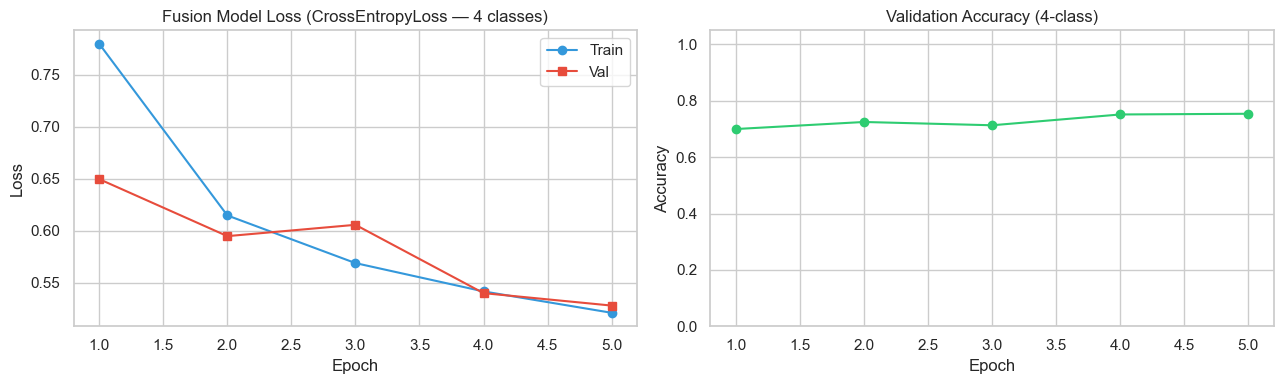

Checkpoints saved to: d:\PhishScamSense\ml\checkpoints
  fusion_model.pt
  xgb_classifier.pkl
  xgb_classifier.json


In [59]:
import pickle

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_range = range(1, EPOCHS + 1)
axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train", color="#3498db")
axes[0].plot(epochs_range, history["val_loss"],   marker="s", label="Val",   color="#e74c3c")
axes[0].set_title("Fusion Model Loss (CrossEntropyLoss — 4 classes)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, history["val_acc"], marker="o", color="#2ecc71")
axes[1].set_title("Validation Accuracy (4-class)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05); axes[1].grid(True)

plt.tight_layout()
plt.show()

# Save checkpoints
torch.save(fusion_model.state_dict(), CHECKPOINT_DIR / "fusion_model.pt")
with open(CHECKPOINT_DIR / "xgb_classifier.pkl", "wb") as f:
    pickle.dump(xgb_clf, f)
xgb_clf.save_model(str(CHECKPOINT_DIR / "xgb_classifier.json"))

print(f"Checkpoints saved to: {CHECKPOINT_DIR}")
print("  fusion_model.pt")
print("  xgb_classifier.pkl")
print("  xgb_classifier.json")

---

# Part 05 — Evaluation & Analysis

---

# 05 - Evaluation & Analysis
## PhishScamSense: Real-Time Multimodal Phishing Defense

This notebook covers:
1. Loading trained model checkpoints from notebook 04
2. Building a held-out test set from CIC-Bell-DNS2021
3. 4-class classification metrics: Accuracy, Macro-F1, per-class Precision/Recall
4. Confusion matrix (4×4) visualization
5. Per-class ROC curves (one-vs-rest)
6. XGBoost feature importance analysis
7. Error analysis: which classes get confused with which

In [60]:
import sys
import os
import pickle
import logging
from pathlib import Path

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import DistilBertModel, DistilBertTokenizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

from ml.src.data.data_loader import load_cic_bell_dns2021
from ml.src.features.url_features import extract_url_features

sns.set_theme(style="whitegrid")
logging.basicConfig(level=logging.WARNING)

CLASS_NAMES    = ["benign", "phishing", "malware", "spam"]
CLASS_COLORS   = ["#2ecc71", "#e74c3c", "#e67e22", "#9b59b6"]
NUM_CLASSES    = 4
CHECKPOINT_DIR = Path(PROJECT_ROOT) / "ml" / "checkpoints"
DATA_DIR       = Path(PROJECT_ROOT) / "data" / "raw"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 5.1 Re-define Models & Load Checkpoints

In [61]:
# ── Model classes — attribute names must match ml/src/models/ exactly ────────
class AttentionLayer(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)
    def forward(self, lstm_output):
        weights = torch.softmax(self.attention(lstm_output), dim=1)
        return torch.sum(weights * lstm_output, dim=1)

class NLPBranch(nn.Module):
    def __init__(self, output_dim=128, lstm_hidden=256, lstm_layers=2, dropout=0.3, freeze_bert=True):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        if freeze_bert:
            for p in self.distilbert.parameters(): p.requires_grad = False
        bh = self.distilbert.config.hidden_size
        self.bilstm = nn.LSTM(bh, lstm_hidden, lstm_layers, batch_first=True, bidirectional=True,
                              dropout=dropout if lstm_layers > 1 else 0)
        self.attention = AttentionLayer(lstm_hidden * 2)
        self.fc = nn.Linear(lstm_hidden * 2, output_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, input_ids, attention_mask):
        x = self.distilbert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        x, _ = self.bilstm(x)
        return self.fc(self.dropout(self.attention(x)))

class MLPBranch(nn.Module):
    def __init__(self, input_dim=23, hidden_dims=None, output_dim=64, dropout=0.3):
        super().__init__()
        if hidden_dims is None: hidden_dims = [128, 64]
        layers = []; prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]; prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.network = nn.Sequential(*layers)
    def forward(self, x): return self.network(x)

class PhishScamSenseFusionModel(nn.Module):
    def __init__(self, num_features=23, nlp_output_dim=128, numerical_output_dim=64, freeze_bert=True):
        super().__init__()
        self.nlp_branch = NLPBranch(output_dim=nlp_output_dim, freeze_bert=freeze_bert)
        self.numerical_branch = MLPBranch(input_dim=num_features, output_dim=numerical_output_dim)
        self.fusion_dim = nlp_output_dim + numerical_output_dim
    def forward(self, input_ids, attention_mask, numerical_features):
        return torch.cat([self.nlp_branch(input_ids, attention_mask),
                          self.numerical_branch(numerical_features)], dim=1)

class URLTokenizer:
    def __init__(self, max_length=128):
        self.tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
        self.max_length = max_length
    def tokenize(self, urls):
        return self.tokenizer(urls, padding=True, truncation=True,
                              max_length=self.max_length, return_tensors="pt")

# ── Load checkpoints ──────────────────────────────────────────────────────────
fusion_model = PhishScamSenseFusionModel(num_features=23)
ckpt_path = CHECKPOINT_DIR / "fusion_model.pt"
if ckpt_path.exists():
    fusion_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print("Fusion model loaded from checkpoint.")
else:
    print("WARNING: No checkpoint found. Run notebook 04 first.")

xgb_path = CHECKPOINT_DIR / "xgb_classifier.pkl"
if xgb_path.exists():
    with open(xgb_path, "rb") as f:
        xgb_clf = pickle.load(f)
    print("XGBoost model loaded from checkpoint.")
else:
    print("WARNING: No XGBoost checkpoint found. Run notebook 04 first.")

fusion_model.eval()
tokenizer = URLTokenizer()

C:\Users\dimas\AppData\Local\Temp\ipykernel_41444\995413720.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fusion_model.load_state_dict(torch.load(ckpt_path, map_locat

Fusion model loaded from checkpoint.
XGBoost model loaded from checkpoint.


## 5.2 Build Test Set from CIC-Bell-DNS2021

In [62]:
import random

TEST_PER_CLASS = 500   # held-out test samples per class
SEED = 99              # different seed from NB04 to avoid overlap

urls_all, labels_all = load_cic_bell_dns2021(DATA_DIR, max_benign=TEST_PER_CLASS * 4, seed=SEED)

rng = random.Random(SEED)
per_class: dict[int, list[str]] = {i: [] for i in range(NUM_CLASSES)}
for url, lbl in zip(urls_all, labels_all):
    per_class[lbl].append(url)

test_urls, test_labels = [], []
for lbl, url_list in per_class.items():
    sample = rng.sample(url_list, min(TEST_PER_CLASS, len(url_list)))
    test_urls.extend(sample)
    test_labels.extend([lbl] * len(sample))
    print(f"  {CLASS_NAMES[lbl]:12s}: {len(sample):,}")

test_urls   = np.array(test_urls,   dtype=object)
test_labels = np.array(test_labels, dtype=np.int32)

# Extract features and embed
num_feat_test = torch.tensor(
    [list(extract_url_features(u).values()) for u in test_urls],
    dtype=torch.float32,
)

CHUNK = 64
all_emb = []
fusion_model.eval()
for i in range(0, len(test_urls), CHUNK):
    batch_urls = test_urls[i:i+CHUNK].tolist()
    enc = tokenizer.tokenize(batch_urls)
    with torch.no_grad():
        emb = fusion_model(enc["input_ids"].to(device),
                           enc["attention_mask"].to(device),
                           num_feat_test[i:i+CHUNK].to(device)).cpu().numpy()
    all_emb.append(emb)

test_emb = np.vstack(all_emb)
y_true   = test_labels
y_pred   = xgb_clf.predict(test_emb).astype(int)
y_proba  = xgb_clf.predict_proba(test_emb)   # shape (n, 4)

print(f"\nTest set embedded: {test_emb.shape}")
print(f"Predictions complete.")

INFO:ml.src.data.data_loader:Loaded 2,000 benign URLs
INFO:ml.src.data.data_loader:Loaded 16,304 phishing URLs
INFO:ml.src.data.data_loader:Loaded 26,894 malware URLs
INFO:ml.src.data.data_loader:Loaded 8,254 spam URLs
INFO:ml.src.data.data_loader:Total dataset: 53,452 URLs


  benign      : 500
  phishing    : 500
  malware     : 500
  spam        : 500

Test set embedded: (2000, 192)
Predictions complete.


## 5.3 Classification Metrics

In [63]:
acc      = accuracy_score(y_true, y_pred)
macro_p  = precision_score(y_true, y_pred, average="macro",  zero_division=0)
macro_r  = recall_score(y_true, y_pred,    average="macro",  zero_division=0)
macro_f1 = f1_score(y_true, y_pred,        average="macro",  zero_division=0)
wt_f1    = f1_score(y_true, y_pred,        average="weighted", zero_division=0)

print("=" * 45)
print("  4-CLASS EVALUATION METRICS")
print("=" * 45)
print(f"  {'Accuracy':<20} {acc:.4f}")
print(f"  {'Macro Precision':<20} {macro_p:.4f}")
print(f"  {'Macro Recall':<20} {macro_r:.4f}")
print(f"  {'Macro F1':<20} {macro_f1:.4f}")
print(f"  {'Weighted F1':<20} {wt_f1:.4f}")
print("=" * 45)
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

  4-CLASS EVALUATION METRICS
  Accuracy             0.7245
  Macro Precision      0.7594
  Macro Recall         0.7245
  Macro F1             0.7215
  Weighted F1          0.7215

              precision    recall  f1-score   support

      benign     0.6080    0.7260    0.6618       500
    phishing     0.9671    1.0000    0.9833       500
     malware     0.5623    0.7040    0.6252       500
        spam     0.9000    0.4680    0.6158       500

    accuracy                         0.7245      2000
   macro avg     0.7594    0.7245    0.7215      2000
weighted avg     0.7594    0.7245    0.7215      2000



## 5.4 Confusion Matrix

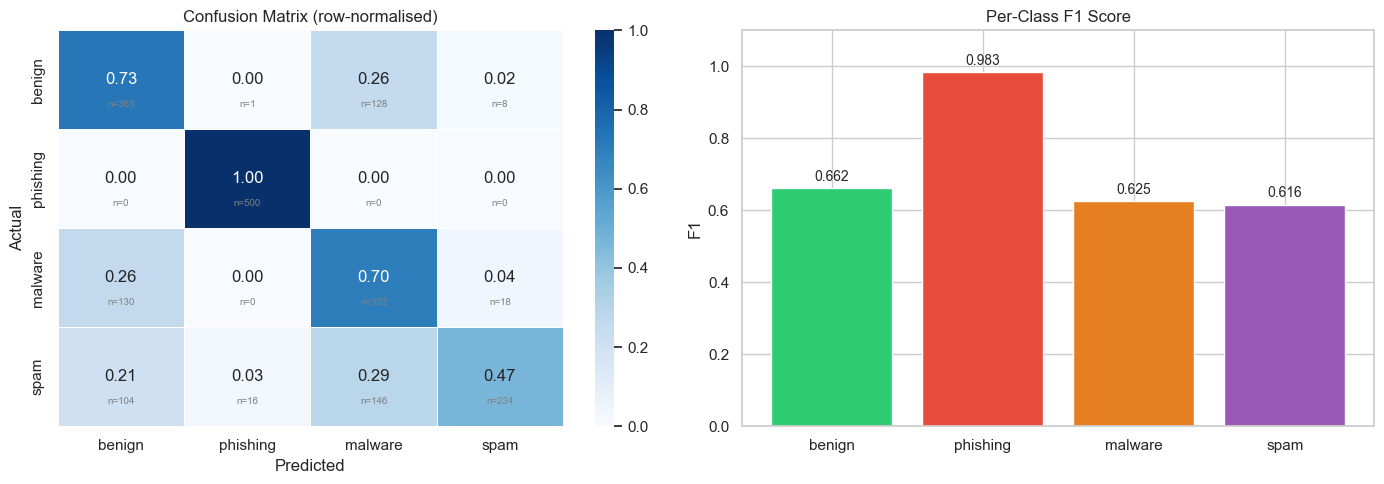


Raw confusion matrix:
          benign  phishing  malware  spam
benign       363         1      128     8
phishing       0       500        0     0
malware      130         0      352    18
spam         104        16      146   234


In [64]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 4×4 confusion matrix ─────────────────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, vmin=0, vmax=1)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix (row-normalised)")

# Raw counts annotation overlay
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        axes[0].text(j + 0.5, i + 0.75, f"n={cm[i,j]}",
                     ha="center", va="center", fontsize=7, color="grey")

# ── Per-class metric bars ─────────────────────────────────────────────────────
per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
axes[1].bar(CLASS_NAMES, per_class_f1, color=CLASS_COLORS, edgecolor="white")
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Per-Class F1 Score")
axes[1].set_ylabel("F1")
for i, v in enumerate(per_class_f1):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nRaw confusion matrix:")
print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_string())

## 5.5 ROC Curve & Precision-Recall Curve

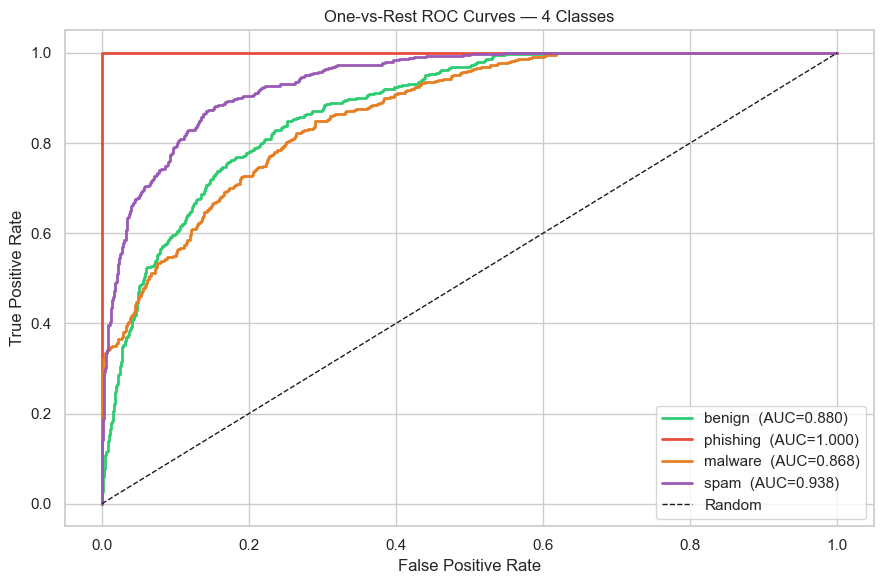

In [65]:
# Per-class ROC curves (one-vs-rest)
y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))  # (n, 4)

fig, ax = plt.subplots(figsize=(9, 6))
for i, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("One-vs-Rest ROC Curves — 4 Classes")
ax.legend(loc="lower right")
ax.grid(True)
plt.tight_layout()
plt.show()

## 5.6 XGBoost Feature Importance

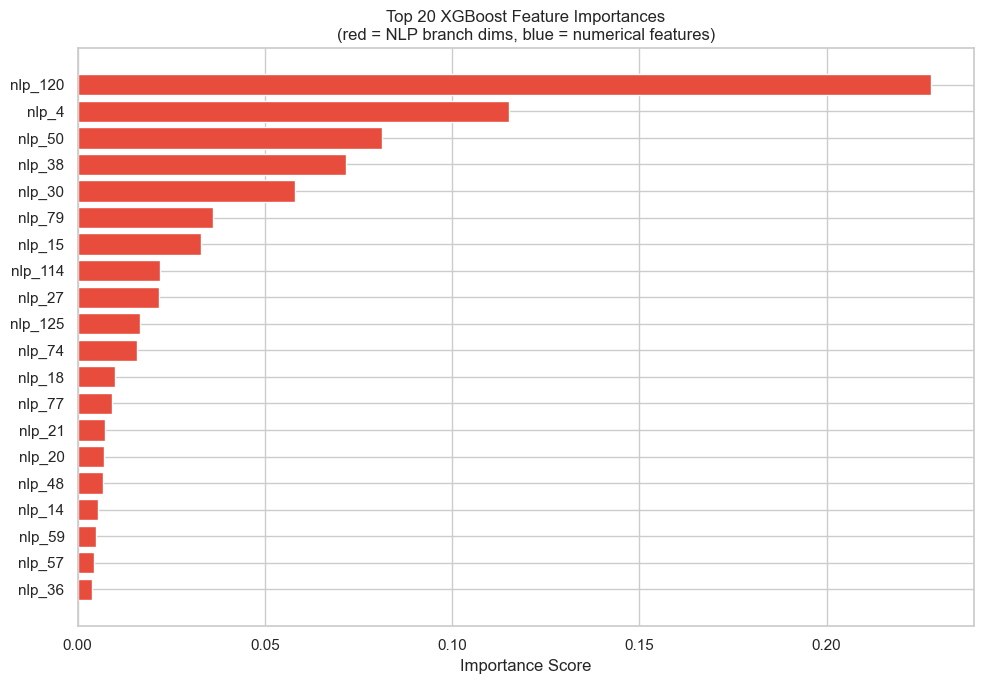


Fused feature vector: 192 dims  (128 NLP + 23 numerical = 151 total)


In [66]:
FEATURE_NAMES = [
    "url_length", "hostname_length", "path_length", "num_dots", "num_hyphens",
    "num_underscores", "num_slashes", "num_query_params", "num_fragments",
    "num_digits", "num_special_chars", "url_entropy", "hostname_entropy",
    "has_ip_address", "has_punycode", "has_port", "has_https", "has_at_symbol",
    "has_double_slash_redirect", "subdomain_count", "tld_length",
    "consecutive_consonants_max", "vowel_ratio",
]

# Fused dims: 0-127 = NLP branch, 128-191 = numerical branch
importance  = xgb_clf.feature_importances_
nlp_labels  = [f"nlp_{i}" for i in range(128)]
num_labels  = FEATURE_NAMES          # 23 numerical features
all_labels_imp = nlp_labels + num_labels

top_k = 20
sorted_idx  = np.argsort(importance)[::-1][:top_k]
top_labels  = [all_labels_imp[i] for i in sorted_idx]
top_scores  = importance[sorted_idx]
top_colors  = ["#e74c3c" if l.startswith("nlp") else "#3498db" for l in top_labels]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(top_k), top_scores[::-1], color=top_colors[::-1], edgecolor="white")
ax.set_yticks(range(top_k))
ax.set_yticklabels(top_labels[::-1])
ax.set_xlabel("Importance Score")
ax.set_title(f"Top {top_k} XGBoost Feature Importances\n"
             f"(red = NLP branch dims, blue = numerical features)")
plt.tight_layout()
plt.show()

print(f"\nFused feature vector: {len(importance)} dims  "
      f"(128 NLP + {len(FEATURE_NAMES)} numerical = {128 + len(FEATURE_NAMES)} total)")

## 5.7 Error Analysis: False Positives & False Negatives

In [67]:
results_df = pd.DataFrame({
    "url":        test_urls,
    "true_label": y_true,
    "pred_label": y_pred,
    "true_class": [CLASS_NAMES[i] for i in y_true],
    "pred_class": [CLASS_NAMES[i] for i in y_pred],
    "confidence": y_proba.max(axis=1).round(4),
})
results_df["correct"] = results_df["true_label"] == results_df["pred_label"]

misclassified = results_df[~results_df["correct"]].copy()
print(f"Total misclassified: {len(misclassified):,} / {len(results_df):,}  "
      f"({len(misclassified)/len(results_df)*100:.1f}%)\n")

# Confusion pairs: which classes get confused most?
confusion_pairs = (
    misclassified
    .groupby(["true_class", "pred_class"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print("Most frequent misclassification pairs:")
print(confusion_pairs.to_string(index=False))

# Sample 3 errors per confusion pair
print("\n--- Misclassified URL samples ---")
for _, row in confusion_pairs.head(6).iterrows():
    subset = misclassified[
        (misclassified["true_class"] == row["true_class"]) &
        (misclassified["pred_class"] == row["pred_class"])
    ].head(2)
    for _, s in subset.iterrows():
        print(f"  [{s['true_class']} → {s['pred_class']}]  conf={s['confidence']:.3f}  {s['url'][:80]}")

Total misclassified: 551 / 2,000  (27.6%)

Most frequent misclassification pairs:
true_class pred_class  count
      spam    malware    146
   malware     benign    130
    benign    malware    128
      spam     benign    104
   malware       spam     18
      spam   phishing     16
    benign       spam      8
    benign   phishing      1

--- Misclassified URL samples ---
  [spam → malware]  conf=0.397  ahmqv.com
  [spam → malware]  conf=0.621  cgfdxve.top
  [malware → benign]  conf=0.657  solomikeartwork.com
  [malware → benign]  conf=0.738  narbhaveecareers.com
  [benign → malware]  conf=0.577  gzdaj.gov.cn
  [benign → malware]  conf=0.989  themascloset.co.za
  [spam → benign]  conf=0.553  acumate.online
  [spam → benign]  conf=0.966  cnrll.com
  [malware → spam]  conf=0.743  earnvoucher.review
  [malware → spam]  conf=0.470  htpbox.info
  [spam → phishing]  conf=0.826  xn--80aa3abq5bzcb.xn--p1ai
  [spam → phishing]  conf=0.961  xn--90aoqnp5a4a.xn--p1ai


---

# Part 06 — Inference & Export

---

# 06 - Inference & Export
## PhishScamSense: Real-Time Multimodal Phishing Defense

This notebook covers:
1. Load trained model checkpoints
2. Single URL 4-class inference pipeline
3. Batch inference pipeline with timing benchmark
4. Build Counting Bloom Filter from all threat-class URLs (phishing + malware + spam)
5. Export Bloom Filter, fusion model, and XGBoost for production

In [68]:
import sys
import os
import pickle
import json
import logging
from pathlib import Path

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import torch
import torch.nn as nn
from transformers import DistilBertModel, DistilBertTokenizer

from ml.src.data.data_loader import load_cic_bell_dns2021
from ml.src.features.url_features import extract_url_features

logging.basicConfig(level=logging.WARNING)

CLASS_NAMES    = ["benign", "phishing", "malware", "spam"]
NUM_CLASSES    = 4
CHECKPOINT_DIR = Path(PROJECT_ROOT) / "ml" / "checkpoints"
DATA_DIR       = Path(PROJECT_ROOT) / "data" / "raw"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 6.1 Load Model Components

In [69]:
# ── Model classes — attribute names must match ml/src/models/ exactly ────────
class AttentionLayer(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size, 1)
    def forward(self, lstm_output):
        weights = torch.softmax(self.attention(lstm_output), dim=1)
        return torch.sum(weights * lstm_output, dim=1)

class NLPBranch(nn.Module):
    def __init__(self, output_dim=128, lstm_hidden=256, lstm_layers=2, dropout=0.3, freeze_bert=True):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        if freeze_bert:
            for p in self.distilbert.parameters(): p.requires_grad = False
        bh = self.distilbert.config.hidden_size
        self.bilstm = nn.LSTM(bh, lstm_hidden, lstm_layers, batch_first=True, bidirectional=True,
                              dropout=dropout if lstm_layers > 1 else 0)
        self.attention = AttentionLayer(lstm_hidden * 2)
        self.fc = nn.Linear(lstm_hidden * 2, output_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, input_ids, attention_mask):
        x = self.distilbert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        x, _ = self.bilstm(x)
        return self.fc(self.dropout(self.attention(x)))

class MLPBranch(nn.Module):
    def __init__(self, input_dim=23, hidden_dims=None, output_dim=64, dropout=0.3):
        super().__init__()
        if hidden_dims is None: hidden_dims = [128, 64]
        layers = []; prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]; prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.network = nn.Sequential(*layers)
    def forward(self, x): return self.network(x)

class PhishScamSenseFusionModel(nn.Module):
    def __init__(self, num_features=23, nlp_output_dim=128, numerical_output_dim=64, freeze_bert=True):
        super().__init__()
        self.nlp_branch = NLPBranch(output_dim=nlp_output_dim, freeze_bert=freeze_bert)
        self.numerical_branch = MLPBranch(input_dim=num_features, output_dim=numerical_output_dim)
        self.fusion_dim = nlp_output_dim + numerical_output_dim
    def forward(self, input_ids, attention_mask, numerical_features):
        return torch.cat([self.nlp_branch(input_ids, attention_mask),
                          self.numerical_branch(numerical_features)], dim=1)

class URLTokenizer:
    def __init__(self, max_length=128):
        self.tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
        self.max_length = max_length
    def tokenize(self, urls):
        return self.tokenizer(urls, padding=True, truncation=True,
                              max_length=self.max_length, return_tensors="pt")

# ── Load checkpoints ──────────────────────────────────────────────────────────
fusion_model = PhishScamSenseFusionModel(num_features=23)
ckpt_path = CHECKPOINT_DIR / "fusion_model.pt"
if ckpt_path.exists():
    fusion_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print("Fusion model loaded.")
else:
    print("WARNING: Run notebook 04 first to generate checkpoints.")

xgb_path = CHECKPOINT_DIR / "xgb_classifier.pkl"
if xgb_path.exists():
    with open(xgb_path, "rb") as f:
        xgb_clf = pickle.load(f)
    print("XGBoost model loaded.")
else:
    print("WARNING: No XGBoost checkpoint found. Run notebook 04 first.")

fusion_model.eval()
tokenizer = URLTokenizer()

C:\Users\dimas\AppData\Local\Temp\ipykernel_41444\2131718636.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fusion_model.load_state_dict(torch.load(ckpt_path, map_loca

Fusion model loaded.
XGBoost model loaded.


## 6.2 Single URL Inference Pipeline

In [70]:
RISK_THRESHOLD = 0.6   # minimum confidence to flag as a threat

def predict_url(url: str) -> dict:
    """
    Full 4-class inference pipeline for a single URL.
    Returns the predicted class, per-class probabilities, and risk level.
    """
    tokens = tokenizer.tokenize([url])
    num_feat = torch.tensor([list(extract_url_features(url).values())],
                            dtype=torch.float32).to(device)

    fusion_model.eval()
    with torch.no_grad():
        fused = fusion_model(tokens["input_ids"].to(device),
                             tokens["attention_mask"].to(device),
                             num_feat).cpu().numpy()

    proba     = xgb_clf.predict_proba(fused)[0]   # shape (4,)
    pred_cls  = int(proba.argmax())
    pred_name = CLASS_NAMES[pred_cls]
    confidence = float(proba[pred_cls])
    is_threat  = pred_name != "benign" and confidence >= RISK_THRESHOLD

    return {
        "url":        url,
        "class":      pred_name,
        "confidence": round(confidence, 4),
        "is_threat":  is_threat,
        "risk_level": "HIGH" if confidence > 0.8 else "MEDIUM" if confidence > 0.5 else "LOW",
        "proba":      {name: round(float(p), 4) for name, p in zip(CLASS_NAMES, proba)},
    }


# Test cases: one per class
test_cases = [
    "https://www.google.com",
    "http://paypa1-secure.com/signin/update-billing",
    "amazon.co.uk.security-check.ga",
    "0900259.com",
]

print(f"{'URL':<55} {'Class':<10} {'Conf':<8} {'Threat':<8} Risk")
print("-" * 100)
for url in test_cases:
    r = predict_url(url)
    print(f"{url:<55} {r['class']:<10} {r['confidence']:<8.4f} {str(r['is_threat']):<8} {r['risk_level']}")
    print(f"  probabilities: {r['proba']}")

URL                                                     Class      Conf     Threat   Risk
----------------------------------------------------------------------------------------------------
https://www.google.com                                  phishing   0.9998   True     HIGH
  probabilities: {'benign': 0.0001, 'phishing': 0.9998, 'malware': 0.0001, 'spam': 0.0}
http://paypa1-secure.com/signin/update-billing          phishing   0.9999   True     HIGH
  probabilities: {'benign': 0.0, 'phishing': 0.9999, 'malware': 0.0001, 'spam': 0.0}
amazon.co.uk.security-check.ga                          malware    0.9991   True     HIGH
  probabilities: {'benign': 0.0007, 'phishing': 0.0001, 'malware': 0.9991, 'spam': 0.0002}
0900259.com                                             phishing   0.9952   True     HIGH
  probabilities: {'benign': 0.0004, 'phishing': 0.9952, 'malware': 0.0034, 'spam': 0.001}


## 6.3 Batch Inference Pipeline

In [71]:
import pandas as pd
import time

def predict_batch(urls: list[str], batch_size: int = 32) -> pd.DataFrame:
    """Batch inference with micro-batching. Returns DataFrame with 4-class results."""
    all_results = []
    for i in range(0, len(urls), batch_size):
        batch = urls[i:i+batch_size]
        tokens  = tokenizer.tokenize(batch)
        num_feat = torch.tensor(
            [list(extract_url_features(u).values()) for u in batch],
            dtype=torch.float32,
        )
        fusion_model.eval()
        with torch.no_grad():
            fused = fusion_model(tokens["input_ids"].to(device),
                                 tokens["attention_mask"].to(device),
                                 num_feat.to(device)).cpu().numpy()

        proba_batch = xgb_clf.predict_proba(fused)   # (batch, 4)
        for url, proba in zip(batch, proba_batch):
            pred_cls  = int(proba.argmax())
            pred_name = CLASS_NAMES[pred_cls]
            conf      = float(proba[pred_cls])
            all_results.append({
                "url":        url,
                "class":      pred_name,
                "confidence": round(conf, 4),
                "is_threat":  pred_name != "benign" and conf >= RISK_THRESHOLD,
                "risk_level": "HIGH" if conf > 0.8 else "MEDIUM" if conf > 0.5 else "LOW",
                **{f"p_{name}": round(float(p), 4) for name, p in zip(CLASS_NAMES, proba)},
            })
    return pd.DataFrame(all_results)


# Benchmark
bench_urls = test_cases * 5   # 20 URLs
start = time.time()
batch_df = predict_batch(bench_urls, batch_size=8)
elapsed = time.time() - start

print(f"Batch inference: {len(bench_urls)} URLs in {elapsed:.2f}s  "
      f"({elapsed/len(bench_urls)*1000:.1f} ms/URL)\n")
print(batch_df[["url", "class", "confidence", "is_threat", "risk_level"]].to_string(index=False))

Batch inference: 20 URLs in 0.19s  (9.5 ms/URL)

                                           url    class  confidence  is_threat risk_level
                        https://www.google.com phishing      0.9998       True       HIGH
http://paypa1-secure.com/signin/update-billing phishing      0.9999       True       HIGH
                amazon.co.uk.security-check.ga  malware      0.9990       True       HIGH
                                   0900259.com  malware      0.3476      False        LOW
                        https://www.google.com phishing      0.9998       True       HIGH
http://paypa1-secure.com/signin/update-billing phishing      0.9999       True       HIGH
                amazon.co.uk.security-check.ga  malware      0.9990       True       HIGH
                                   0900259.com  malware      0.3476      False        LOW
                        https://www.google.com phishing      0.9998       True       HIGH
http://paypa1-secure.com/signin/update-billing phis

## 6.4 Build Counting Bloom Filter for Browser Extension

The Bloom Filter is the client-side first-pass check inside the browser extension.
- URL **not in filter** → guaranteed safe, no network call needed
- URL **in filter** → call the backend ML service to verify

The filter now covers **all three threat classes** (phishing + malware + spam)
loaded directly from the CIC-Bell-DNS2021 raw files.

In [72]:
class CountingBloomFilter:
    """
    Counting Bloom Filter matching the TypeScript implementation in
    extension/lib/bloom-filter.ts.

    Supports add, contains, and remove.
    False positive rate ≈ (1 - e^(-k*n/m))^k
    """

    def __init__(self, size: int = 1_000_000, num_hashes: int = 7):
        self.size = size
        self.num_hashes = num_hashes
        self.buckets = [0] * size

    def _hash(self, value: str, seed: int) -> int:
        h = seed
        for char in value:
            h = (h * 31 + ord(char)) & 0xFFFFFFFF
        return h % self.size

    def add(self, value: str):
        for i in range(self.num_hashes):
            idx = self._hash(value, i)
            if self.buckets[idx] < 255:
                self.buckets[idx] += 1

    def contains(self, value: str) -> bool:
        return all(self.buckets[self._hash(value, i)] > 0 for i in range(self.num_hashes))

    def remove(self, value: str):
        if not self.contains(value): return
        for i in range(self.num_hashes):
            idx = self._hash(value, i)
            if self.buckets[idx] > 0:
                self.buckets[idx] -= 1

    def false_positive_rate(self, num_items: int) -> float:
        import math
        return (1 - math.exp(-self.num_hashes * num_items / self.size)) ** self.num_hashes

    def export_data(self) -> list[int]: return self.buckets
    def load_data(self, data: list[int]): self.buckets = list(data)


# ── Load threat URLs from CIC-Bell-DNS2021 (phishing + malware + spam) ───────
print("Loading threat URLs from CIC-Bell-DNS2021…")
urls_all, labels_all = load_cic_bell_dns2021(DATA_DIR, max_benign=0, seed=42)
# max_benign=0 → skip benign entirely, load only threat classes

threat_urls = [u for u, l in zip(urls_all, labels_all) if l != 0]
threat_labels = [l for l in labels_all if l != 0]

from collections import Counter
label_counts = Counter(threat_labels)
for lbl, cnt in sorted(label_counts.items()):
    print(f"  {CLASS_NAMES[lbl]:12s}: {cnt:,}")
print(f"  Total threats : {len(threat_urls):,}")

# Use production-size filter; adjust size for memory constraints
bloom = CountingBloomFilter(size=1_000_000, num_hashes=7)
for url in threat_urls:
    bloom.add(url)

# Verify
print("\nBloom Filter lookup tests:")
for url in threat_urls[:3]:
    print(f"  THREAT  in_filter={bloom.contains(url)}  {url[:60]}")
for url in ["https://www.google.com", "https://github.com", "https://python.org"]:
    print(f"  BENIGN  in_filter={bloom.contains(url)}  {url}")

fpr = bloom.false_positive_rate(len(threat_urls))
print(f"\nFilter size:         {bloom.size:,}")
print(f"Items inserted:      {len(threat_urls):,}")
print(f"False positive rate: {fpr:.6f}  ({fpr*100:.4f}%)")

Loading threat URLs from CIC-Bell-DNS2021…


INFO:ml.src.data.data_loader:Loaded 0 benign URLs
INFO:ml.src.data.data_loader:Loaded 16,304 phishing URLs
INFO:ml.src.data.data_loader:Loaded 26,894 malware URLs
INFO:ml.src.data.data_loader:Loaded 8,254 spam URLs
INFO:ml.src.data.data_loader:Total dataset: 51,452 URLs


  phishing    : 16,304
  malware     : 26,894
  spam        : 8,254
  Total threats : 51,452

Bloom Filter lookup tests:
  THREAT  in_filter=True  http://programafidelidadeitacard2.cf/
  THREAT  in_filter=True  http://professorjosesilveira.com/wp-content/themes/conversti
  THREAT  in_filter=True  http://revcaint.com/directing/www.cibc.mobi/accountConfirm.p
  BENIGN  in_filter=False  https://www.google.com
  BENIGN  in_filter=False  https://github.com
  BENIGN  in_filter=False  https://python.org

Filter size:         1,000,000
Items inserted:      51,452
False positive rate: 0.000231  (0.0231%)


## 6.5 Export Bloom Filter & Models for Production

In [73]:
EXPORT_DIR = os.path.join(PROJECT_ROOT, "ml", "exports")
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1. Export Bloom Filter as JSON (consumed by FastAPI /threats/bloom-filter endpoint)
bloom_export = {
    "filter": bloom.export_data(),
    "size": bloom.size,
    "num_hashes": bloom.num_hashes,
    "version": "0.1.0",
    "num_items": len(threat_urls),
    "false_positive_rate": bloom.false_positive_rate(len(threat_urls)),
}
bloom_path = os.path.join(EXPORT_DIR, "bloom_filter.json")
with open(bloom_path, "w") as f:
    json.dump(bloom_export, f)
print(f"Bloom filter exported: {bloom_path}")

# 2. Export fusion model state dict
fusion_export_path = os.path.join(EXPORT_DIR, "fusion_model.pt")
torch.save(fusion_model.state_dict(), fusion_export_path)
print(f"Fusion model exported: {fusion_export_path}")

# 3. Export XGBoost model (pickle)
xgb_export_path = os.path.join(EXPORT_DIR, "xgb_classifier.pkl")
with open(xgb_export_path, "wb") as f:
    pickle.dump(xgb_clf, f)
print(f"XGBoost model exported: {xgb_export_path}")

# 4. Export XGBoost as JSON (portable format)
xgb_json_path = os.path.join(EXPORT_DIR, "xgb_classifier.json")
xgb_clf.save_model(xgb_json_path)
print(f"XGBoost JSON exported:  {xgb_json_path}")

print(f"\nAll exports saved to: {EXPORT_DIR}")

Bloom filter exported: d:\PhishScamSense\ml\exports\bloom_filter.json
Fusion model exported: d:\PhishScamSense\ml\exports\fusion_model.pt
XGBoost model exported: d:\PhishScamSense\ml\exports\xgb_classifier.pkl
XGBoost JSON exported:  d:\PhishScamSense\ml\exports\xgb_classifier.json

All exports saved to: d:\PhishScamSense\ml\exports


## 6.6 End-to-End System Summary

Verify the complete PhishScamSense pipeline works end-to-end.

In [74]:
def phishscamsense_pipeline(url: str) -> dict:
    """
    Simulates the full two-stage PhishScamSense pipeline:
      Stage 1: Bloom Filter (O(1), client-side, zero network)
      Stage 2: ML 4-class inference (only when Bloom Filter fires)
    """
    bloom_hit = bloom.contains(url)

    if not bloom_hit:
        return {
            "url":       url,
            "stage":     "bloom_filter",
            "class":     "benign",
            "is_threat": False,
            "confidence": 0.0,
            "risk_level": "LOW",
            "note":      "Cleared by Bloom Filter — no ML call needed",
        }

    result = predict_url(url)
    result["stage"] = "ml_inference"
    result["note"]  = "Bloom Filter fired → ML inference performed"
    return result


print("=== PhishScamSense Two-Stage Pipeline Demo ===\n")
demo_urls = [
    "https://www.google.com",              # benign — not in bloom
    "https://python.org",                  # benign — not in bloom
    threat_urls[0],                        # phishing — in bloom
    threat_urls[len(threat_urls)//2],      # malware or spam — in bloom
]

for url in demo_urls:
    r = phishscamsense_pipeline(url)
    status = "THREAT " if r["is_threat"] else "SAFE   "
    print(f"[{r['stage']:<14}]  {status}  class={r['class']:<10}  conf={r['confidence']:.3f}")
    print(f"  URL : {url[:80]}")
    print(f"  Note: {r['note']}\n")

=== PhishScamSense Two-Stage Pipeline Demo ===

[bloom_filter  ]  SAFE     class=benign      conf=0.000
  URL : https://www.google.com
  Note: Cleared by Bloom Filter — no ML call needed

[bloom_filter  ]  SAFE     class=benign      conf=0.000
  URL : https://python.org
  Note: Cleared by Bloom Filter — no ML call needed

[ml_inference  ]  THREAT   class=phishing    conf=1.000
  URL : http://programafidelidadeitacard2.cf/
  Note: Bloom Filter fired → ML inference performed

[ml_inference  ]  SAFE     class=benign      conf=0.876
  URL : sixgoody.com
  Note: Bloom Filter fired → ML inference performed



In [75]:
import matplotlib.pyplot as plt

# Text-based architecture summary
print("=" * 62)
print("  PHISHSCAMSENSE PIPELINE SUMMARY")
print("=" * 62)
print()
print("  Browser Extension (Client-Side)")
print("  ┌───────────────────────────────────────────┐")
print("  │  URL → Counting Bloom Filter              │")
print("  │        O(1) lookup, zero network          │")
print("  │        Covers: phishing + malware + spam  │")
print("  │        If MISS → safe (no API call)       │")
print("  │        If HIT  → call backend API         │")
print("  └────────────────┬──────────────────────────┘")
print("                   │ (only ~5% of URLs)")
print("  ┌────────────────▼──────────────────────────┐")
print("  │  FastAPI Backend  POST /api/v1/predict    │")
print("  └────────────────┬──────────────────────────┘")
print("                   │")
print("  ┌────────────────▼──────────────────────────┐")
print("  │  BentoML Inference Service                │")
print("  │  ┌─────────────┬─────────────────────┐   │")
print("  │  │  NLP Branch │  Numerical Branch   │   │")
print("  │  │  DistilBERT │  23 features        │   │")
print("  │  │  BiLSTM     │  [128, 64] hidden   │   │")
print("  │  │  Attention  │                     │   │")
print("  │  │  → 128d     │  → 64d              │   │")
print("  │  └──────┬──────┴──────────┬──────────┘   │")
print("  │         └──── concat ─────┘              │")
print("  │                192d fused                 │")
print("  │                    ↓                      │")
print("  │         XGBoost 4-class Classifier        │")
print("  │   benign / phishing / malware / spam      │")
print("  └───────────────────────────────────────────┘")
print()
print("  Dataset: CIC-Bell-DNS2021")
print(f"    benign:    ~988k (subsampled to 100k for training)")
print(f"    phishing:    ~16k")
print(f"    malware:     ~27k")
print(f"    spam:         ~8k")
print(f"    Bloom filter: {len(threat_urls):,} threat URLs inserted")
print(f"    FPR:          {bloom.false_positive_rate(len(threat_urls))*100:.4f}%")
print("=" * 62)

  PHISHSCAMSENSE PIPELINE SUMMARY

  Browser Extension (Client-Side)
  ┌───────────────────────────────────────────┐
  │  URL → Counting Bloom Filter              │
  │        O(1) lookup, zero network          │
  │        Covers: phishing + malware + spam  │
  │        If MISS → safe (no API call)       │
  │        If HIT  → call backend API         │
  └────────────────┬──────────────────────────┘
                   │ (only ~5% of URLs)
  ┌────────────────▼──────────────────────────┐
  │  FastAPI Backend  POST /api/v1/predict    │
  └────────────────┬──────────────────────────┘
                   │
  ┌────────────────▼──────────────────────────┐
  │  BentoML Inference Service                │
  │  ┌─────────────┬─────────────────────┐   │
  │  │  NLP Branch │  Numerical Branch   │   │
  │  │  DistilBERT │  23 features        │   │
  │  │  BiLSTM     │  [128, 64] hidden   │   │
  │  │  Attention  │                     │   │
  │  │  → 128d     │  → 64d              │   │
  │  └──────